In [11]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re

import time
import torch
import torch.nn

import random
import pickle


In [12]:
if torch.cuda.is_available():
    print(torch.cuda.current_device())
    print(torch.cuda.device(0))
    print(torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA is not available.')

0
1
NVIDIA A100-PCIE-40GB


In [13]:
import torch.backends.cudnn as cudnn
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    # work on a single GPU or CPU
    cudnn.benchmark=True
    print(torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    cudnn.benchmark=False

print(device)

NVIDIA A100-PCIE-40GB
cuda:0


In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# 1. Load model

In [15]:
import io
import torch
# Reference: https://github.com/pytorch/pytorch/issues/16797#issuecomment-633423219
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else: 
            return super().find_class(module, name)

In [7]:
### remove nan values
def remove_nan(y):
    nan_idx = np.where(pd.isna(y))[0]
    return y.drop(y.index[nan_idx], axis=0)

In [8]:
### Discretize the continuous variables into 2 or 3 categories - low, (moderate), high
def if_discretize(y_nonan):
    if y_nonan.dtype.name == 'object':
        y_disc = y_nonan
    elif len(np.unique(y_nonan)) <= 6:
        y_disc = y_nonan
    elif np.quantile(y_nonan, 1/2)==np.min(y_nonan):
        y_disc = pd.Series(np.where(y_nonan==np.min(y_nonan), 'Min', 'Not Min'), index=y_nonan.index)
    elif np.quantile(y_nonan, 1/2)==np.max(y_nonan):
        y_disc = pd.Series(np.where(y_nonan==np.max(y_nonan), 'Not Max', 'Max'), index=y_nonan.index)
    elif np.quantile(y_nonan, 1/3)==np.min(y_nonan) or np.quantile(y_nonan, 2/3)==np.max(y_nonan):
        y_disc = pd.qcut(y_nonan, 2, labels=['Low', 'High'])
    else:
        y_disc = pd.qcut(y_nonan, 3, labels=['Low', 'Moderate', 'High'])
    
    ### remove categories with less than 5 instances (8/2 training/testing split)
    u, c = np.unique(y_disc, return_counts=True)
    idx = np.where(np.isin(y_disc, u[c<5]))
    return y_disc.drop(index=y_disc.index[idx])

In [9]:
def balanced_over_sampling(X, y, random_seed=123):
    np.random.seed(random_seed)
    unique_value, unique_value_counts = np.unique(y, return_counts=True)
    train_class_max = np.max(unique_value_counts)
    train_samples_idx = []
    for i, y_unique in enumerate(unique_value):
        train_one_class_idx = np.where(y==y_unique)[0]
        train_one_sample_idx = np.concatenate([train_one_class_idx,
                                               np.random.choice(train_one_class_idx, 
                                                                size=train_class_max-len(train_one_class_idx), replace=True)])
        train_samples_idx.append(train_one_sample_idx)
    train_balanced_idx = np.random.permutation(np.concatenate(train_samples_idx))
    return X[train_balanced_idx], y[train_balanced_idx]

In [10]:
class Classifier(torch.nn.Module):
    def __init__(self, n_in_features, net_hidden_structure, n_out_features, dropout_rate):
        super(Classifier, self).__init__()
        net_fcs = []
        structure = net_hidden_structure
        net_in_shape = n_in_features
        for i, net_n_hidden_nodes in enumerate(structure):
            net_fcs.append(torch.nn.Linear(net_in_shape, net_n_hidden_nodes))
            net_fcs.append(torch.nn.BatchNorm1d(net_n_hidden_nodes))
            net_fcs.append(torch.nn.ReLU6())
            net_fcs.append(torch.nn.Dropout(p=dropout_rate))
            net_in_shape = net_n_hidden_nodes
        net_fcs.append(torch.nn.Linear(net_in_shape, n_out_features))
        self.net_fcs = torch.nn.ModuleList(net_fcs)
        
    def forward(self, x):
        net_fcs = self.net_fcs
        for net_fc in net_fcs:
            x = net_fc(x)
        return x

In [11]:
from torch.utils.data import Dataset, DataLoader
class Dataset(Dataset):
    """Self-defined dataset."""

    def __init__(self, X, y):
        """
        Args:
            X: microbiome data
            y: response data
        """
        self.X = torch.from_numpy(X).float() if not torch.is_tensor(X) else X.float()
        self.y = torch.LongTensor(y) if not torch.is_tensor(y) else y.long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [12]:
def load_model(X,y, disease, dropout_rate, weight_decay,
              lr=0.001, momentum=0.9, random_state=123, device='cuda:0', print_loss=True,
              save_folder='./'):
    
    import torch
    import torch.nn as nn
    import random
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    random.seed(random_state)
    #torch.set_deterministic(True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        
    ###
    y_nonan = remove_nan(y)
    y_nonan_disc = if_discretize(y_nonan)
    X_nonan = X.loc[y_nonan_disc.index,:]
    
    ### training, testing split
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(X_nonan, y_nonan_disc, test_size=0.2, 
                                                        random_state=random_state, stratify=y_nonan_disc)
    X_train_balanced, y_train_balanced = balanced_over_sampling(np.array(X_train), np.array(y_train))

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(y_nonan_disc)
    y_train_balanced_le = le.transform(y_train_balanced)
    y_test_le = le.transform(y_test)
    classes = le.classes_
    label_dim = len(classes)

    classifier = Classifier(n_in_features=X.shape[1], net_hidden_structure = [512, 128, 32, 8], 
                            n_out_features=label_dim, dropout_rate=dropout_rate)
    classifier.to(device)
    optimizer = torch.optim.SGD(classifier.parameters(), lr=lr, momentum=momentum, weight_decay = weight_decay)
    
    model_save_path = os.path.join(save_folder, 'models/{}/{}'.format(disease, y.name))

    ### If you are running on a CPU-only machine, add "map_location=torch.device('cpu')".
    if torch.cuda.is_available():
        checkpoint = torch.load(os.path.join(model_save_path, '{}.pth'.format(y_train.name)),
                                map_location=torch.device('cuda:0'))
    else:
        checkpoint = torch.load(os.path.join(model_save_path, '{}.pth'.format(y_train.name)), 
                                map_location=torch.device('cpu'))
        
    hist = checkpoint['history']
    classifier.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    return classifier, optimizer, hist, X_test, y_test_le, classes, X_nonan, y_nonan_disc

In [13]:
def micro_avg_auc(y_test_le, classes, pred_proba):
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    
    y_test = label_binarize(classes[y_test_le], classes=classes)
    if y_test.shape[1]==1:
        y_test = np.hstack((1-y_test, y_test))
    y_score = pred_proba.cpu().numpy()
    
    # Compute micro-average ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    return roc_auc

# 2. LRP

In [14]:
def get_activations(classifier, X, device='cuda:0'):
    activations = []
    classifier.to(device)
    classifier.eval()
    with torch.no_grad():
        _acti = torch.tensor(np.array([X])).float().to(device)
        for i, _module in enumerate(list(classifier.modules())[1]):
            _acti = _module(_acti)
            activations.append(_acti)
    return activations

In [15]:
### Reference: https://git.tu-berlin.de/gmontavon/lrp-tutorial
def rho1(w, a):
    aw = a.cpu().detach().numpy() * w.cpu().detach().numpy()
    return ((aw > 0) * w.cpu().detach().numpy()).squeeze()
def rho2(w, a):
    aw = a.cpu().detach().numpy() * w.cpu().detach().numpy()
    return ((aw < 0) * w.cpu().detach().numpy()).squeeze()
### LRP-epsilon
def incr(z, epsilon_coef=0.1): 
    return z + epsilon_coef * (z**2).mean()**.5

In [16]:
### Reference: https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py
import copy
def newlayer1(layer,g):

    layer = copy.deepcopy(layer)

    layer.weight = torch.nn.Parameter(torch.tensor(g(layer.weight)).to(device))
    layer.bias   = torch.nn.Parameter(torch.tensor(np.maximum(0,layer.bias.cpu().detach().numpy())).to(device))

    return layer

def newlayer2(layer,g):

    layer = copy.deepcopy(layer)

    layer.weight = torch.nn.Parameter(torch.tensor(g(layer.weight)).to(device))
    layer.bias   = torch.nn.Parameter(torch.tensor(np.minimum(0,layer.bias.cpu().detach().numpy())).to(device))

    return layer

In [17]:
def relprop(a, layer, R_k, alpha=2., beta=1., epsilon_coef=0.):
    import copy
    a1 = copy.deepcopy(a)
    z1 = newlayer1(layer, lambda x: rho1(x,a1.data)).forward(a1)         # step 1
    z1 = incr(z1, epsilon_coef)                                          # step 1
    if z1.abs().sum() == 0:
        R_j1 = torch.zeros_like(a1)  # Nothing to propagate
    else:
        s1 = R_k/(z1+1e-9)                                                   # step 2
        (z1*s1.data).sum().backward()                                        # step 3
        c1 = a1.grad                                                         # step 3
        R_j1 = alpha*a1*c1                                                   # step 4
    
    a2 = copy.deepcopy(a)
    z2 = newlayer2(layer, lambda x: rho2(x,a2.data)).forward(a2)          # step 1
    z2 = incr(z2, epsilon_coef)                                           # step 1
    if z2.abs().sum() == 0:
        R_j2 = torch.zeros_like(a2)  # Nothing to propagate
    else:
        s2 = R_k/(z2+1e-9)                                                    # step 2
        (z2*s2.data).sum().backward()                                         # step 3
        c2 = a2.grad                                                          # step 3
        R_j2 = beta*a2*c2                                                     # step 4
    return R_j1 - R_j2

In [18]:
def LRP(classifier, X_onerow, feature_idx, classes, device='cuda:0'):
    A = get_activations(classifier, X_onerow, device=device)
    A.insert(0, torch.FloatTensor(np.array(X_onerow)).to(device))
    LAYER = list(classifier.modules())[1]
    L = len(LAYER)
    R = [None]*(L+1)
    R[-1] = torch.tensor([0.0]*len(classes)).float().to(device)
    
    for idx in feature_idx:
        R[-1][idx] = A[-1].squeeze()[idx]
    for l in range(L)[::-1]:
        if isinstance(LAYER[l],torch.nn.Linear):
            A[l] = (A[l]).requires_grad_(True)
            R[l] = relprop(A[l], LAYER[l], R[l+1])
        else:
            R[l] = R[l+1]
    return R, A

In [19]:
### Reference: B-LRP - https://github.com/lapalap/B-LRP/blob/master/B_LRP_MNIST.ipynb

# Function for MinMax Normalisation of Relevances

def normalise_relevance(relevance_matrix):
    a = relevance_matrix.min()
    b = relevance_matrix.max()
    
    if (a == 0.) & (b == 0.):
        return relevance_matrix
    if (a >= 0.):
        return (relevance_matrix>=0.) * relevance_matrix/b
    if (b <= 0.):
        return - ((relevance_matrix<=0.) * relevance_matrix/a)
    else:
        return (relevance_matrix>0.) * relevance_matrix/b  - ((relevance_matrix<=0.)*relevance_matrix/a)


In [20]:
def lrp_analysis_immune(classifier, X_microbiome, y_nonan_disc, classes, 
                          quantile_cut = 0.95, device='cuda:0', random_state=123):
    
    import torch
    import torch.nn as nn
    import random
    import numpy as np
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    random.seed(random_state)
    #torch.set_deterministic(True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        
    R_0_immune, prediction = [], []
    for i in range(X_microbiome.shape[0]):
        y_feature_idx = np.where(classes==y_nonan_disc.iloc[i])[0]
        R_onerow, A_onerow = LRP(classifier, X_microbiome.iloc[i,:], y_feature_idx,
                                 classes, device=device)
        R_0_onerow = normalise_relevance(R_onerow[0]) ### Add minmax normalization here
        predict_onerow = A_onerow[-1].squeeze()[y_feature_idx]
        R_0_immune.append(R_0_onerow.cpu().detach().numpy())
        prediction.append(predict_onerow.cpu().detach().numpy())
    R_0_immune = np.array(R_0_immune)
    prediction = np.array(prediction)
    
    ### Analysis on Relevance Score
    ### 1. Influence by row sum of absolute value of R0 (care about both excitatory and inhibitory effects)
    influence_by_microbe = np.sum(np.abs(R_0_immune), axis=0)
    ### 2. significant count (by quantile/p-value)
    R_0_immune_qcut = np.zeros(R_0_immune.shape)
    for i in range(R_0_immune.shape[0]):
        cutoff = np.quantile(R_0_immune[i,:], quantile_cut)
        R_0_immune_qcut[i,:] = R_0_immune[i,:] >= cutoff
    ### 3. spearman correlation
    from scipy.stats import spearmanr
    correlation = []
    for j in range(R_0_immune.shape[1]):
        if np.std(R_0_immune[:, j]) > 0 and np.std(prediction) > 0:
            correlation.append(spearmanr(R_0_immune[:, j], prediction).correlation)
        else:
            correlation.append(None)  # Append None for undefined cases when there are constant columns
    return R_0_immune, R_0_immune_qcut, influence_by_microbe, correlation

In [21]:
def lrp_analysis_immune_all_cols(disease, nan_percentage_cutoff=0.4, quantile_cut = 0.95, auc_cutoff = [0.6, 0.6],
                                   device='cuda:0', save_folder='./', dropout_rate=0., weight_decay=0.):
    immune_variables_disease_microbiome_clean = \
        pd.read_pickle('./data/processed data/{}_immune_variables_disease_microbiome_clean.pkl'.format(disease))
    
    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    col_idx = immune_variables_disease_microbiome_clean.shape[1] - X_microbiome.shape[1] - 4
    y_immune_all = immune_variables_disease_microbiome_clean.iloc[:,2:col_idx]
    
    ### Remove columns that have >40% (or a preset value) nan values for all samples
    y_immune_all_rmv_idx = np.where(y_immune_all.\
                          apply(lambda x: sum(pd.isna(x))/len(x), axis=0) > nan_percentage_cutoff)[0]
    y_immune_all.drop(columns=y_immune_all.columns[y_immune_all_rmv_idx], inplace=True)

    ### Remove columns with a single response
    y_1value_idx = y_immune_all.apply(lambda x: len(np.unique(if_discretize(remove_nan(x)))), axis=0)==1
    y_immune_all.drop(columns=y_immune_all.columns[y_1value_idx], inplace=True)
            
    ### Remove columns with < 5 instances after discretization
    y_less5_ins_idx = y_immune_all.apply(lambda y: if_discretize(remove_nan(y)).shape[0] < 5, axis=0)
    y_immune_all.drop(columns=y_immune_all.columns[y_less5_ins_idx], inplace=True)
    
    print(y_immune_all.shape)
    
    import pickle
    with open(os.path.join(save_folder, 'results/{}/{}_prediction_result_dict.pkl'.\
                           format(disease, disease)), 'rb') as f:
        prediction_result_dict = pickle.load(f)
    
    # Screen by AUC value --> Micro avg. AUC >= auc_cutoff[0] AND Weighted avg. AUC >= auc_cutoff[1]
    micro_auc_immune_variables = np.array([prediction_result_dict['auc'][x][0] for x in y_immune_all.columns])
    weighted_auc_immune_variables = np.array([prediction_result_dict['auc'][x][1] for x in y_immune_all.columns])
    y_above_auc_idx = np.where((micro_auc_immune_variables>=auc_cutoff[0]) & \
                               (weighted_auc_immune_variables>=auc_cutoff[1]))[0]
    
    R_0_immune_all, R_0_immune_qcut_all, influence_by_microbe_all, correlation_all = \
        [], [], [], []
    for i in y_above_auc_idx:
        ### Load model
        classifier, optimizer, hist, X_test, y_test_le, classes, X_nonan, y_nonan_disc = \
            load_model(X=X_microbiome, y=y_immune_all.iloc[:,i],
                       disease=disease, dropout_rate=dropout_rate, weight_decay=weight_decay)
        R_0_immune, R_0_immune_qcut, influence_by_microbe, correlation = \
            lrp_analysis_immune(classifier, X_nonan, y_nonan_disc, classes, 
                                  quantile_cut = quantile_cut, device=device)
        R_0_immune_all.append(R_0_immune)
        R_0_immune_qcut_all.append(R_0_immune_qcut)
        influence_by_microbe_all.append(influence_by_microbe)
        correlation_all.append(correlation)
    y_col_names = y_immune_all.columns.values[y_above_auc_idx]
    
    lrp_result_dict = dict()
    lrp_result_dict['R_0_immune_all'] = R_0_immune_all
    lrp_result_dict['R_0_immune_qcut_all'] = R_0_immune_qcut_all
    lrp_result_dict['influence_by_microbe_all'] = np.array(influence_by_microbe_all)
    lrp_result_dict['correlation_all'] = np.array(correlation_all)
    lrp_result_dict['y_col_names'] = y_col_names
    
    import pickle
    result_save_folder = os.path.join(save_folder, 'results/LRP/{}'.format(disease))
    os.makedirs(result_save_folder, exist_ok=True)
    
    with open(os.path.join(result_save_folder, 'lrp_result_dict.pkl'.format(disease)), "wb") as f:
        pickle.dump(lrp_result_dict, f)
        
    return lrp_result_dict

In [22]:
%%time
COAD_lrp_result_dict = lrp_analysis_immune_all_cols('COAD', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.2, weight_decay=0.)
print(len(COAD_lrp_result_dict['y_col_names']))
print(COAD_lrp_result_dict['y_col_names'])

(246, 54)
13
['Homozygous in all three loci = 1' 'Immune Subtype' 'Leukocyte Fraction'
 'TGF-beta Response' 'TCR Richness' 'Th1 Cells'
 'Dendritic Cells Activated' 'Dendritic Cells Resting' 'Macrophages M0'
 'Neutrophils' 'NK Cells Activated' 'T Cells CD4 Naive' 'Macrophages']
CPU times: user 4min 54s, sys: 19min 19s, total: 24min 14s
Wall time: 2min 31s


In [23]:
%%time
STAD_lrp_result_dict = lrp_analysis_immune_all_cols('STAD', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.4, weight_decay=0.1)
print(len(STAD_lrp_result_dict['y_col_names']))
print(STAD_lrp_result_dict['y_col_names'])

(380, 52)
10
['homo HLA-A =1' 'homo HLA-C =1' 'Homozygous in all three loci = 1'
 'BCR Shannon' 'TCR Richness' 'Th2 Cells' 'Eosinophils'
 'T Cells CD4 Naive' 'T Cells Follicular Helper' 'Lymphocytes']
CPU times: user 4min 58s, sys: 17min 51s, total: 22min 49s
Wall time: 3min 22s


In [24]:
%%time
LUAD_lrp_result_dict = lrp_analysis_immune_all_cols('LUAD', device=device, nan_percentage_cutoff=0.4, dropout_rate=0., weight_decay=0.01)
print(len(LUAD_lrp_result_dict['y_col_names']))
print(LUAD_lrp_result_dict['y_col_names'])

(502, 54)
6
['Homozygous in at least one locus = 1' 'Homozygous in all three loci = 1'
 'B Cells Memory' 'Eosinophils' 'Mast Cells Activated'
 'T Cells gamma delta']
CPU times: user 3min, sys: 9min 42s, total: 12min 42s
Wall time: 2min 22s


In [25]:
%%time
LUSC_lrp_result_dict = lrp_analysis_immune_all_cols('LUSC', device=device, nan_percentage_cutoff=0.4, dropout_rate=0.4, weight_decay=0.01)
print(len(LUSC_lrp_result_dict['y_col_names']))
print(LUSC_lrp_result_dict['y_col_names'])

(464, 55)
6
['homo HLA-C =1' 'TCR Richness' 'Th1 Cells' 'T Cells CD4 Naive'
 'T Cells gamma delta' 'Macrophages']
CPU times: user 3min 56s, sys: 14min 4s, total: 18min
Wall time: 2min 7s


---

In [16]:
def taxa_to_genera_taxid(taxa_names_with_ids):
    genus_name = [idx.split('-')[0] for idx in taxa_names_with_ids]
    taxid = [int(idx.split('-')[1]) for idx in taxa_names_with_ids]
    return genus_name, taxid

In [17]:
def genus_lvl_marker_by_LRP(disease, influence_quantile_cutoff=0.95, save = True):
    with open(os.path.join(f'./results/LRP/{disease}', 'lrp_result_dict.pkl'), 'rb') as f:
        lrp_result_dict = CPU_Unpickler(f).load()
    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))

    influence_genera_dict, marker_genera_dict = {}, {}
    for i, cov in enumerate(lrp_result_dict['y_col_names']):
        influence_by_cov = pd.Series(lrp_result_dict['influence_by_microbe_all'][i,:],
                                     index=X_microbiome.columns)

        influence_genera_dict[cov] = influence_by_cov.sort_values(ascending=False)
        influence_cutoff = np.quantile(influence_genera_dict[cov], influence_quantile_cutoff)
        marker_genera_dict[cov] = \
            np.array(influence_genera_dict[cov].index)[influence_genera_dict[cov] >= influence_cutoff]
    if save:
        lrp_result_dict['influence_genera_dict'] = influence_genera_dict
        lrp_result_dict['marker_genera_dict'] = marker_genera_dict
        with open(os.path.join(f'./results/LRP/{disease}', 'lrp_result_dict.pkl'), "wb") as f:
            pickle.dump(lrp_result_dict, f)
    return influence_genera_dict, marker_genera_dict

In [28]:
COAD_influence_dict, COAD_marker_genera_dict = genus_lvl_marker_by_LRP('COAD')

In [29]:
STAD_influence_dict, STAD_marker_genera_dict = genus_lvl_marker_by_LRP('STAD')

In [30]:
LUAD_influence_dict, LUAD_marker_genera_dict = genus_lvl_marker_by_LRP('LUAD')

In [31]:
LUSC_influence_dict, LUSC_marker_genera_dict = genus_lvl_marker_by_LRP('LUSC')

## Sorted AUC scores

In [18]:
def sorted_auc(disease, print_disease_name=True):
    import os
    import pickle
    with open(os.path.join(f'./results/{disease}', f'{disease}_prediction_result_dict.pkl'), 'rb') as f:
        prediction_result_dict = CPU_Unpickler(f).load()
    with open(os.path.join(f'./results/LRP/{disease}', 'lrp_result_dict.pkl'), 'rb') as f:
        lrp_result_dict = CPU_Unpickler(f).load()  
    covariate_list = lrp_result_dict['y_col_names']
    all_auc_dict = prediction_result_dict['auc']
    auc_dict = dict(zip(covariate_list, [all_auc_dict[i] for i in covariate_list]))
    sorted_auc_dict = dict(sorted(auc_dict.items(), key = lambda item: item[1][0]+item[1][1], reverse=True))
    sorted_auc_df = pd.DataFrame({'Covariate': sorted_auc_dict.keys(),
                                  '(M-Avg AUC, W-Avg AUC)': sorted_auc_dict.values()},
                                 index = [f'Covariate {i+1}' for i in range(len(covariate_list))])
    if print_disease_name: print(disease)
    return sorted_auc_df

In [19]:
def top_n_genera_name(disease, covariate_list, n=5, m=None):
    with open(os.path.join('./results/LRP/{}/lrp_result_dict.pkl'.format(disease)), "rb") as f:
        lrp_result_dict = CPU_Unpickler(f).load()

    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    influence_by_microbe_all_df = pd.DataFrame(lrp_result_dict['influence_by_microbe_all'],
                                            index=lrp_result_dict['y_col_names'], columns=X_microbiome.columns)
    
    all_taxa_name_list = []
    for cov in covariate_list:
        onerow = influence_by_microbe_all_df.loc[cov, :]
        ranked_name = influence_by_microbe_all_df.columns[np.argsort(onerow.values)[::-1]]
        trailing = '' if m is None else '.'
        ranked_genera_name = [ranked_name[i].split('-')[0][slice(m)] + trailing for i in range(len(onerow))]
        all_taxa_name_list.append(ranked_genera_name[:n])
    all_taxa_name_dict = dict(zip(covariate_list, all_taxa_name_list))
    return all_taxa_name_dict

In [20]:
COAD_sorted_auc_df = sorted_auc('COAD')
COAD_sorted_auc_df

COAD


,Covariate,"(M-Avg AUC, W-Avg AUC)"
Covariate 1,T Cells CD4 Naive,"(0.972, 0.7872340425531915)"
Covariate 2,Homozygous in all three loci = 1,"(0.99, 0.7551020408163265)"
Covariate 3,Immune Subtype,"(0.8784722222222221, 0.6269021739130435)"
Covariate 4,NK Cells Activated,"(0.6824, 0.6944)"
Covariate 5,Neutrophils,"(0.6991999999999999, 0.6310160427807486)"
Covariate 6,Th1 Cells,"(0.656, 0.6523529411764706)"
Covariate 7,Macrophages M0,"(0.6466000000000001, 0.6508199643493761)"
Covariate 8,Dendritic Cells Activated,"(0.6792, 0.6180555555555555)"
Covariate 9,Dendritic Cells Resting,"(0.626, 0.64)"
Covariate 10,TGF-beta Response,"(0.6248, 0.6124242424242424)"


In [21]:
COAD_top_5_full_genera_name = top_n_genera_name('COAD', COAD_sorted_auc_df['Covariate'])

COAD_top_5_genera_name_df = pd.DataFrame({
    'Covariate': COAD_top_5_full_genera_name.keys(),
    'Full_name_top5': COAD_top_5_full_genera_name.values()
})

# read abbreviation dictionary table
top_5_genera_dictionary_df = pd.read_csv('../top_5_genera_dictionary_df.csv')

# build mapping: full name -> abbreviation
top_5_genera_dictionary_dict = dict(
    zip(
        top_5_genera_dictionary_df['Full names'],
        top_5_genera_dictionary_df['Abbreviations']
    )
)

# map top-5 full names to abbreviations using dictionary table
COAD_top_5_abbr_list = []
missing_names = set()

for genera_list in COAD_top_5_genera_name_df['Full_name_top5']:
    abbr_list = []
    for genus in genera_list:
        if genus in top_5_genera_dictionary_dict:
            abbr_list.append(top_5_genera_dictionary_dict[genus])
        else:
            abbr_list.append(None)  
            missing_names.add(genus)
    COAD_top_5_abbr_list.append(abbr_list)

COAD_top_5_genera_name_df['Abbreviations_top5'] = COAD_top_5_abbr_list

# check if anything was missing from the dictionary
if missing_names:
    print("Missing genera in abbreviation dictionary:")
    print(sorted(missing_names))

COAD_top_5_genera_name_df

,Covariate,Full_name_top5,Abbreviations_top5
0,T Cells CD4 Naive,"[Bacillus, Klebsiella, Escherichia, Pseudomona...","[Baci., Kleb., Esch., Pseu.m., Salm.]"
1,Homozygous in all three loci = 1,"[Bacillus, Klebsiella, Escherichia, Salmonella...","[Baci., Kleb., Esch., Salm., Pseu.m.]"
2,Immune Subtype,"[Klebsiella, Escherichia, Bacillus, Salmonella...","[Kleb., Esch., Baci., Salm., Cuti.]"
3,NK Cells Activated,"[Escherichia, Bacillus, Klebsiella, Salmonella...","[Esch., Baci., Kleb., Salm., Cuti.]"
4,Neutrophils,"[Bacillus, Klebsiella, Escherichia, Salmonella...","[Baci., Kleb., Esch., Salm., Pseu.m.]"
5,Th1 Cells,"[Bacillus, Klebsiella, Escherichia, Pseudomona...","[Baci., Kleb., Esch., Pseu.m., Salm.]"
6,Macrophages M0,"[Klebsiella, Escherichia, Bacillus, Pseudomona...","[Kleb., Esch., Baci., Pseu.m., Salm.]"
7,Dendritic Cells Activated,"[Bacillus, Escherichia, Klebsiella, Pseudomona...","[Baci., Esch., Kleb., Pseu.m., Salm.]"
8,Dendritic Cells Resting,"[Bacillus, Escherichia, Klebsiella, Salmonella...","[Baci., Esch., Kleb., Salm., Cuti.]"
9,TGF-beta Response,"[Bacillus, Klebsiella, Escherichia, Pseudomona...","[Baci., Kleb., Esch., Pseu.m., Salm.]"


In [23]:
# load saved LRP results
with open(os.path.join('./results/LRP/COAD', 'lrp_result_dict.pkl'), 'rb') as f:
    lrp_result_dict = CPU_Unpickler(f).load()

# extract marker dict
COAD_marker_genera_dict = lrp_result_dict['marker_genera_dict']

import re
COAD_marker_genera_df = pd.DataFrame({'Features': COAD_sorted_auc_df['Covariate'],
                                      'Microbial biomarkers': [re.sub('[\[\]]', '', str(list(COAD_marker_genera_dict[i]))) for i in COAD_sorted_auc_df['Covariate'].values]})
COAD_marker_genera_df

,Features,Microbial biomarkers
Covariate 1,T Cells CD4 Naive,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."
Covariate 2,Homozygous in all three loci = 1,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."
Covariate 3,Immune Subtype,"'Klebsiella-570', 'Escherichia-561', 'Bacillus..."
Covariate 4,NK Cells Activated,"'Escherichia-561', 'Bacillus-1386', 'Klebsiell..."
Covariate 5,Neutrophils,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."
Covariate 6,Th1 Cells,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."
Covariate 7,Macrophages M0,"'Klebsiella-570', 'Escherichia-561', 'Bacillus..."
Covariate 8,Dendritic Cells Activated,"'Bacillus-1386', 'Escherichia-561', 'Klebsiell..."
Covariate 9,Dendritic Cells Resting,"'Bacillus-1386', 'Escherichia-561', 'Klebsiell..."
Covariate 10,TGF-beta Response,"'Bacillus-1386', 'Klebsiella-570', 'Escherichi..."


In [24]:
STAD_sorted_auc_df = sorted_auc('STAD')
STAD_sorted_auc_df

STAD


,Covariate,"(M-Avg AUC, W-Avg AUC)"
Covariate 1,Homozygous in all three loci = 1,"(0.9974030470914127, 0.9066666666666666)"
Covariate 2,Eosinophils,"(0.9522160664819944, 0.8088235294117647)"
Covariate 3,T Cells CD4 Naive,"(0.9897853185595569, 0.6133333333333333)"
Covariate 4,homo HLA-C =1,"(0.9272853185595568, 0.6190476190476191)"
Covariate 5,homo HLA-A =1,"(0.8843490304709142, 0.6195804195804197)"
Covariate 6,T Cells Follicular Helper,"(0.6301073407202215, 0.6341073271413828)"
Covariate 7,Th2 Cells,"(0.6079466759002771, 0.6186790505675954)"
Covariate 8,TCR Richness,"(0.6064750692520776, 0.6059494324045409)"
Covariate 9,BCR Shannon,"(0.6027209642074507, 0.6046001103143961)"
Covariate 10,Lymphocytes,"(0.6023199445983379, 0.6013209494324044)"


In [25]:
STAD_top_5_full_genera_name = top_n_genera_name('STAD', STAD_sorted_auc_df['Covariate'])

STAD_top_5_genera_name_df = pd.DataFrame({
    'Covariate': STAD_top_5_full_genera_name.keys(),
    'Full_name_top5': STAD_top_5_full_genera_name.values()
})

# read abbreviation dictionary table
top_5_genera_dictionary_df = pd.read_csv('../top_5_genera_dictionary_df.csv')

# build mapping: full name -> abbreviation
top_5_genera_dictionary_dict = dict(
    zip(
        top_5_genera_dictionary_df['Full names'],
        top_5_genera_dictionary_df['Abbreviations']
    )
)

# map top-5 full names to abbreviations using dictionary table
STAD_top_5_abbr_list = []
missing_names = set()

for genera_list in STAD_top_5_genera_name_df['Full_name_top5']:
    abbr_list = []
    for genus in genera_list:
        if genus in top_5_genera_dictionary_dict:
            abbr_list.append(top_5_genera_dictionary_dict[genus])
        else:
            abbr_list.append(None)  
            missing_names.add(genus)
    STAD_top_5_abbr_list.append(abbr_list)

STAD_top_5_genera_name_df['Abbreviations_top5'] = STAD_top_5_abbr_list

# check if anything was missing from the dictionary
if missing_names:
    print("Missing genera in abbreviation dictionary:")
    print(sorted(missing_names))

STAD_top_5_genera_name_df

,Covariate,Full_name_top5,Abbreviations_top5
0,Homozygous in all three loci = 1,"[Escherichia, Klebsiella, Salmonella, Pseudomo...","[Esch., Kleb., Salm., Pseu.m., Ente.b.]"
1,Eosinophils,"[Salmonella, Escherichia, Pseudomonas, Klebsie...","[Salm., Esch., Pseu.m., Kleb., Baci.]"
2,T Cells CD4 Naive,"[Enterobacter, Klebsiella, Escherichia, Salmon...","[Ente.b., Kleb., Esch., Salm., Baci.]"
3,homo HLA-C =1,"[Escherichia, Salmonella, Klebsiella, Pseudomo...","[Esch., Salm., Kleb., Pseu.m., Ente.b.]"
4,homo HLA-A =1,"[Salmonella, Escherichia, Klebsiella, Enteroba...","[Salm., Esch., Kleb., Ente.b., Pseu.m.]"
5,T Cells Follicular Helper,"[Salmonella, Escherichia, Klebsiella, Pseudomo...","[Salm., Esch., Kleb., Pseu.m., Baci.]"
6,Th2 Cells,"[Escherichia, Salmonella, Pseudomonas, Klebsie...","[Esch., Salm., Pseu.m., Kleb., Ente.b.]"
7,TCR Richness,"[Klebsiella, Salmonella, Escherichia, Pseudomo...","[Kleb., Salm., Esch., Pseu.m., Baci.]"
8,BCR Shannon,"[Escherichia, Salmonella, Klebsiella, Pseudomo...","[Esch., Salm., Kleb., Pseu.m., Baci.]"
9,Lymphocytes,"[Salmonella, Escherichia, Klebsiella, Pseudomo...","[Salm., Esch., Kleb., Pseu.m., Ente.b.]"


In [26]:
COAD_top_5_genera_name_df.to_pickle('./results/immune_COAD_top_5_genera_name.pkl')
STAD_top_5_genera_name_df.to_pickle('./results/immune_STAD_top_5_genera_name.pkl')

In [27]:
# load saved LRP results
with open(os.path.join('./results/LRP/STAD', 'lrp_result_dict.pkl'), 'rb') as f:
    lrp_result_dict = CPU_Unpickler(f).load()

# extract marker dict
STAD_marker_genera_dict = lrp_result_dict['marker_genera_dict']

import re
STAD_marker_genera_df = pd.DataFrame({'Features': STAD_sorted_auc_df['Covariate'],
                                      'Microbial biomarkers': [re.sub('[\[\]]', '', str(list(STAD_marker_genera_dict[i]))) for i in STAD_sorted_auc_df['Covariate'].values]})
STAD_marker_genera_df

,Features,Microbial biomarkers
Covariate 1,Homozygous in all three loci = 1,"'Escherichia-561', 'Klebsiella-570', 'Salmonel..."
Covariate 2,Eosinophils,"'Salmonella-590', 'Escherichia-561', 'Pseudomo..."
Covariate 3,T Cells CD4 Naive,"'Enterobacter-547', 'Klebsiella-570', 'Escheri..."
Covariate 4,homo HLA-C =1,"'Escherichia-561', 'Salmonella-590', 'Klebsiel..."
Covariate 5,homo HLA-A =1,"'Salmonella-590', 'Escherichia-561', 'Klebsiel..."
Covariate 6,T Cells Follicular Helper,"'Salmonella-590', 'Escherichia-561', 'Klebsiel..."
Covariate 7,Th2 Cells,"'Escherichia-561', 'Salmonella-590', 'Pseudomo..."
Covariate 8,TCR Richness,"'Klebsiella-570', 'Salmonella-590', 'Escherich..."
Covariate 9,BCR Shannon,"'Escherichia-561', 'Salmonella-590', 'Klebsiel..."
Covariate 10,Lymphocytes,"'Salmonella-590', 'Escherichia-561', 'Klebsiel..."


In [28]:
COAD_marker_genera_df.to_csv('./results/COAD/COAD_marker_genera.csv', index=False)
STAD_marker_genera_df.to_csv('./results/STAD/STAD_marker_genera.csv', index=False)

---

## ROC curves for Figures

In [15]:
def roc_curve_all(disease, fig_save_folder='./figures/ROC', variables=None, fontsize=30, bbox_to_anchor=(1.03, -0.03), 
                  plot_axis='x1y1', plot_num_per_row=5, save_format='pdf'):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import os

    pred_result_save_folder = './results/%s' % disease
    with open(os.path.join(pred_result_save_folder, '{}_prediction_result_dict.pkl'.format(disease)), 'rb') as f:
        prediction_result_dict = CPU_Unpickler(f).load()

    lrp_result_save_folder = './results/LRP/%s' % disease
    with open(os.path.join(lrp_result_save_folder, 'lrp_result_dict.pkl'.format(disease)), "rb") as f:
        lrp_result_dict = CPU_Unpickler(f).load()

    covariate_list = lrp_result_dict['y_col_names']
    all_auc_dict = prediction_result_dict['auc']
    auc_dict = dict(zip(covariate_list, [all_auc_dict[i] for i in covariate_list]))
    sorted_auc_dict = dict(sorted(auc_dict.items(), key = lambda item: item[1][0]+item[1][1], reverse=True))
    
    if variables is None:
        plot_var = list(sorted_auc_dict.keys())
    else:
        plot_var = variables 
        
    n_row = np.ceil(len(plot_var)/plot_num_per_row)
    n_full_col = len(plot_var)%plot_num_per_row if len(plot_var)%plot_num_per_row != 0 else 5
       
    for idx, cov in enumerate(list(plot_var)):
        y_test_cov = prediction_result_dict['y_train_test'][cov][1]

        y_test = label_binarize(y_test_cov.values, classes=prediction_result_dict['classes'][cov])
        if y_test.shape[1]==1:
            y_test = np.hstack((1-y_test, y_test))
        y_score = prediction_result_dict['pred_proba'][cov].cpu().numpy()
        classes = prediction_result_dict['classes'][cov]
        print(cov, '\n', classes)
        
        # Reference: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        tt = dict()
        
        for i, c in enumerate(classes):
            if sum(y_test[:, i]) == 0:
                continue
            fpr[c], tpr[c], tt[c] = roc_curve(y_test[:, i], y_score[:, i])
            roc_auc[c] = auc(fpr[c], tpr[c])
            
        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Compute macro-average ROC curve and ROC area
        # First aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))

        # Then interpolate all ROC curves at this points with prevelence as weights
        mean_tpr = np.zeros_like(all_fpr)
        for i in classes:
            mean_tpr += np.sum(y_test_cov == i) * np.interp(all_fpr, fpr[i], tpr[i])

        # Finally average it and compute weighted average AUC
        mean_tpr /= len(y_test_cov)
        
        mean_tpr = np.insert(mean_tpr, [0, len(mean_tpr)], [0., 1.])
        all_fpr = np.insert(all_fpr, [0, len(all_fpr)], [0., 1.])

        fpr["weighted"] = all_fpr
        tpr["weighted"] = mean_tpr
        roc_auc["weighted"] = auc(fpr["weighted"], tpr["weighted"])
        
        stored_auc = prediction_result_dict['auc'][cov]
        
        fig, ax = plt.subplots(figsize=(8,8))

        # Remove grid and background
        plt.style.use('default')  # Reset to default style
        ax.set_facecolor('white')
        fig.set_facecolor('white')
        plt.grid(False)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        lw = 2
        
#         import matplotlib
#         cmap = matplotlib.cm.get_cmap('Set1')

        plt.plot(
        fpr['micro'],
        tpr['micro'],
        lw=lw,
#         color=cmap(0),
        label=f"M-Avg.: {stored_auc[0]:0.2f}"
        )
        
        plt.plot(
        fpr['weighted'],
        tpr['weighted'],
        lw=lw,
#         color=cmap(1),
        label=f"W-Avg.: {stored_auc[1]:0.2f}"
        )
        legend_properties = {'weight':'bold', 'size':fontsize}
        plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
        
        if plot_axis == 'default':
            if idx%plot_num_per_row == 0 and idx//plot_num_per_row == n_row-1: axis = 'x1y1'
            elif idx%plot_num_per_row == 0: axis = 'x0y1'
            elif idx//plot_num_per_row == n_row-1: axis = 'x1y0'
            elif idx%plot_num_per_row > n_full_col-1  and idx//plot_num_per_row == n_row-2: axis = 'x1y0'
            else: axis = 'x0y0'
        elif plot_axis in ['x1y1', 'x0y1', 'x1y0', 'x0y0']:
            axis = plot_axis
        else:
            raise ValueError("Please choose a value for argument 'axis' among "\
                             "{'default', 'x1y1', 'x0y1', 'x1y0', 'x0y0'}!")
        
        if axis == 'x1y1':
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.set_xlabel("FPR", fontsize=fontsize)
            ax.set_ylabel("TPR", fontsize=fontsize)
            ax.tick_params(axis='both', labelsize=fontsize)
        elif axis == 'x0y1':
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(True)
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.set_ylabel("TPR", fontsize=fontsize)
            ax.tick_params(axis='y', labelsize=fontsize)
        elif axis == 'x1y0':
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(True)
            ax.set_xlabel("FPR", fontsize=fontsize)
            ax.tick_params(axis='x', labelsize=fontsize)
            ax.set_ylabel("")
            ax.set_yticks([])
        elif axis == 'x0y0':
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
        
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.set_ylabel("")
            ax.set_yticks([])
        
        plt.xlim([-0.01, 1.01])
        plt.ylim([-0.01, 1.01])
        
        legend = plt.legend(loc='lower right', bbox_to_anchor=bbox_to_anchor, title=r'$\bf{AUC}$', 
                            frameon=False, prop=legend_properties)
        title = legend.get_title()
        title.set_fontsize(fontsize)
        plt.show()
        
        os.makedirs(f"{fig_save_folder}/{disease}", exist_ok=True)
        fig.savefig(f"{fig_save_folder}/{disease}/{idx}_{cov}_{axis}.{save_format}", bbox_inches='tight')

COAD
T Cells CD4 Naive 
 ['Min' 'Not Min']


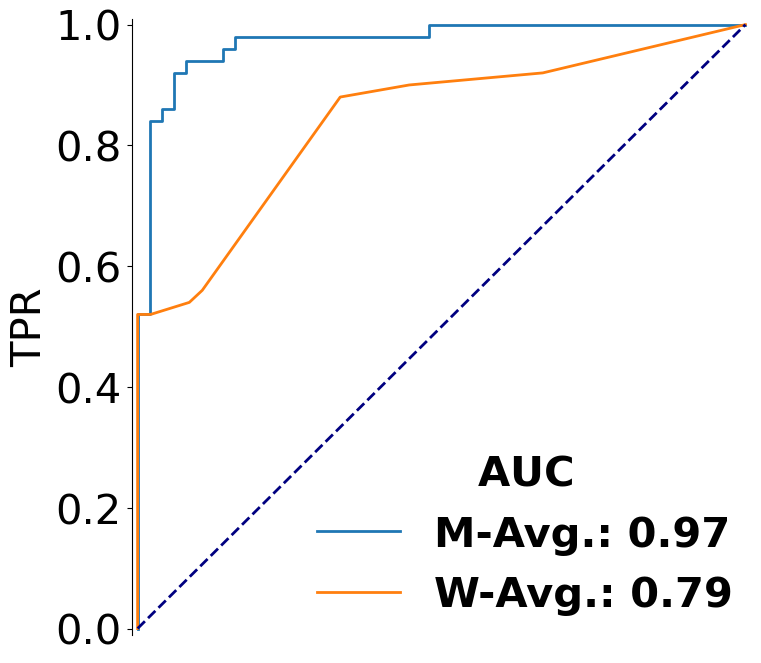

Homozygous in all three loci = 1 
 [0. 1.]


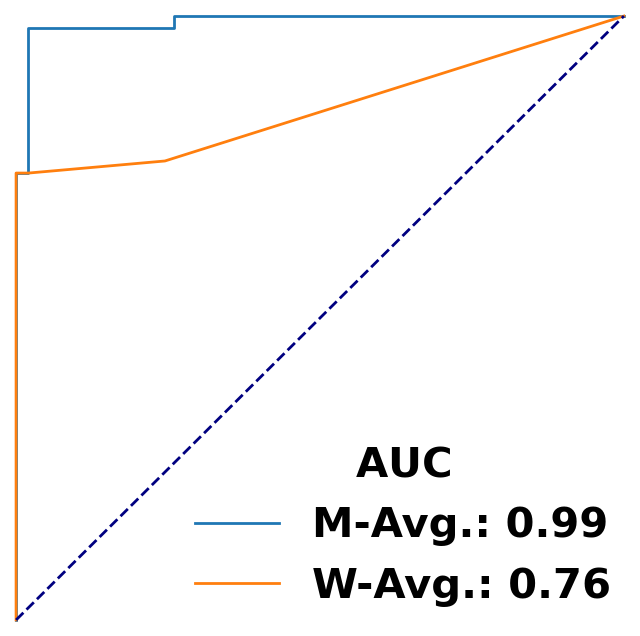

Immune Subtype 
 ['C1' 'C2' 'C4']


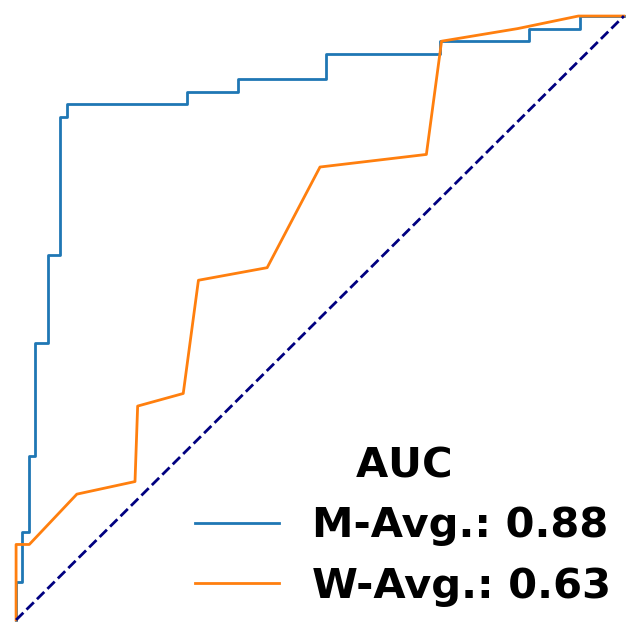

NK Cells Activated 
 ['High' 'Low']


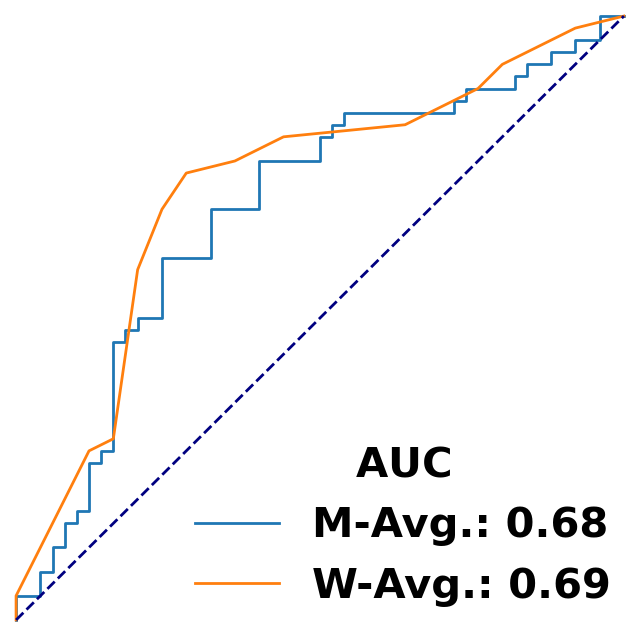

Neutrophils 
 ['Min' 'Not Min']


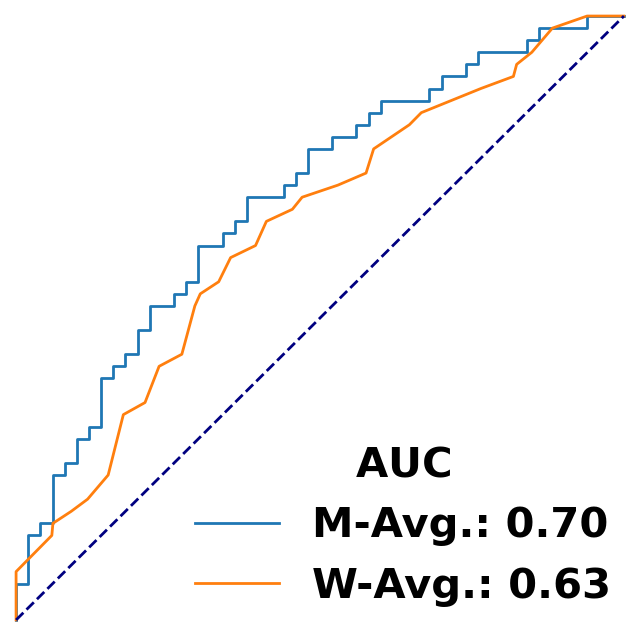

Th1 Cells 
 ['High' 'Low' 'Moderate']


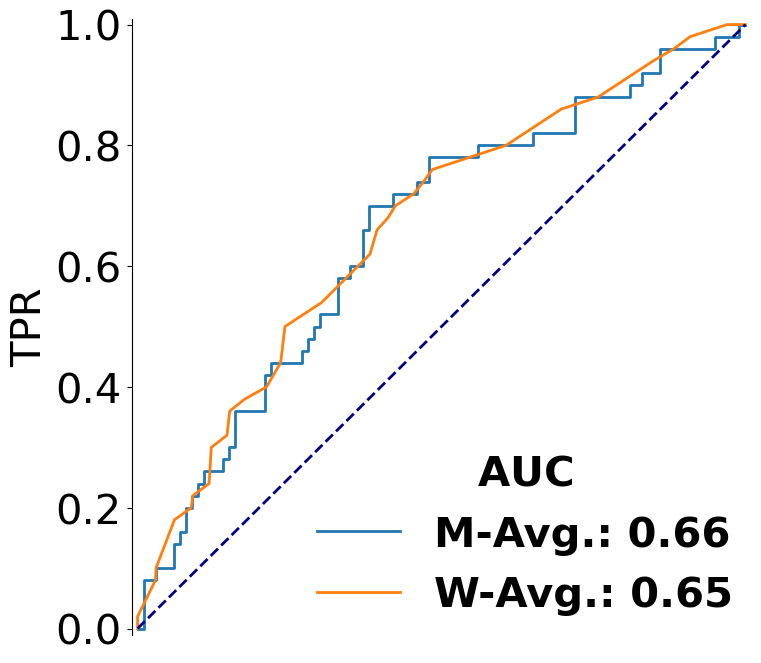

Macrophages M0 
 ['High' 'Low' 'Moderate']


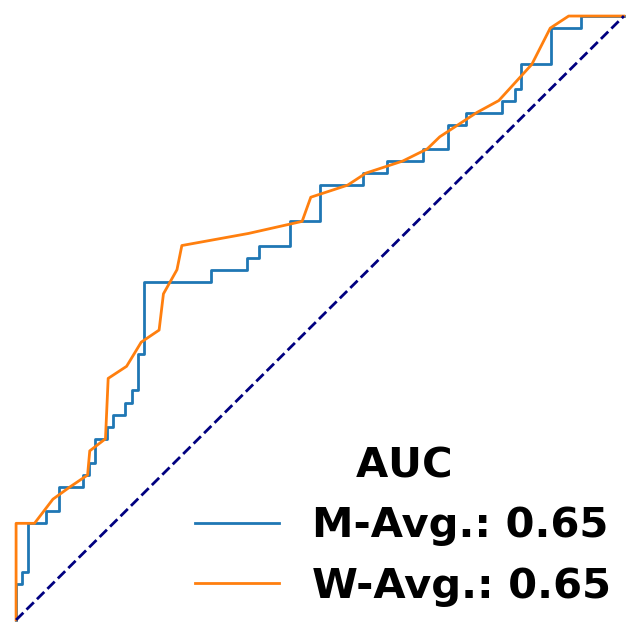

Dendritic Cells Activated 
 ['Min' 'Not Min']


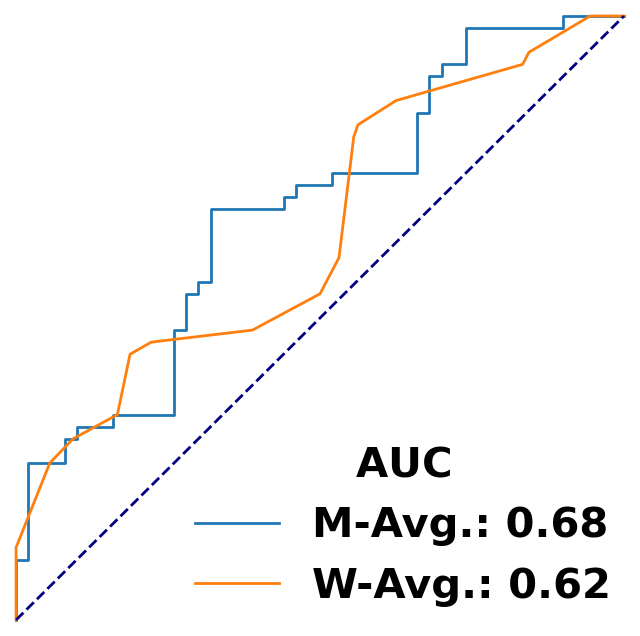

Dendritic Cells Resting 
 ['High' 'Low']


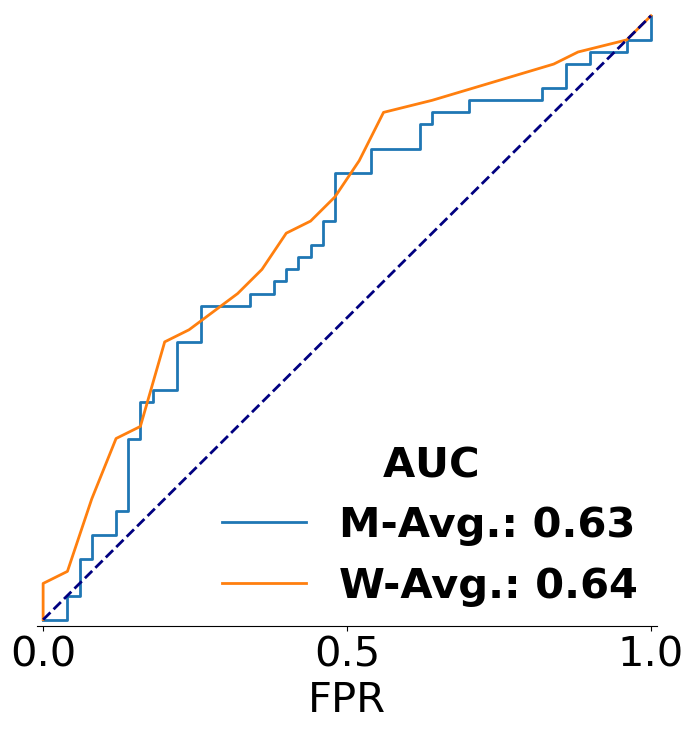

TGF-beta Response 
 ['High' 'Low' 'Moderate']


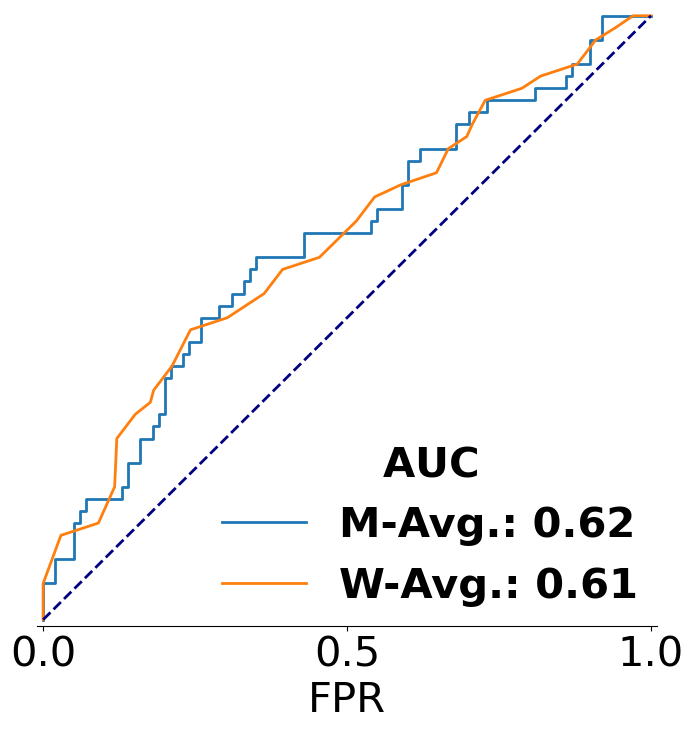

Leukocyte Fraction 
 ['High' 'Low' 'Moderate']


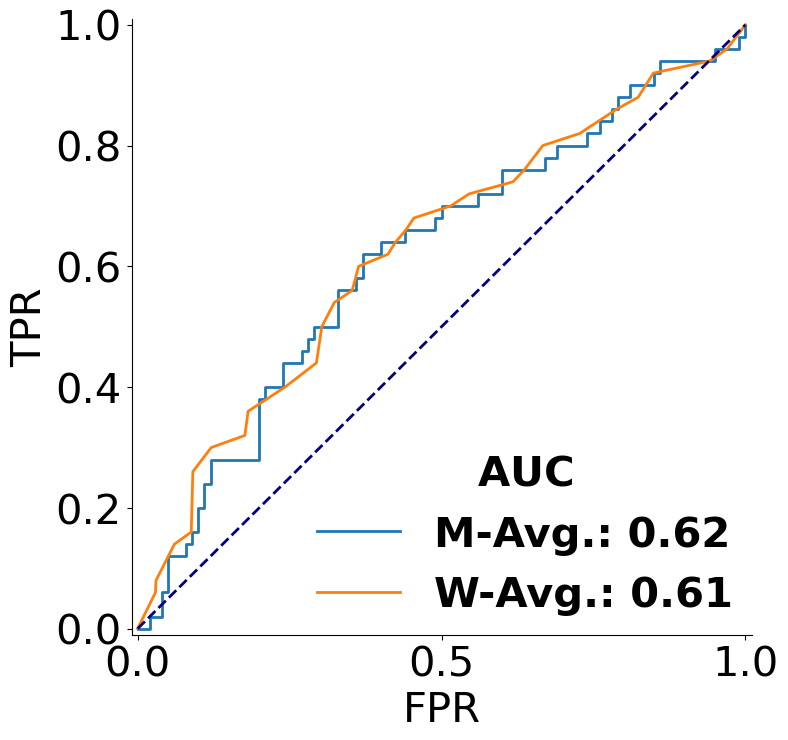

TCR Richness 
 ['High' 'Low' 'Moderate']


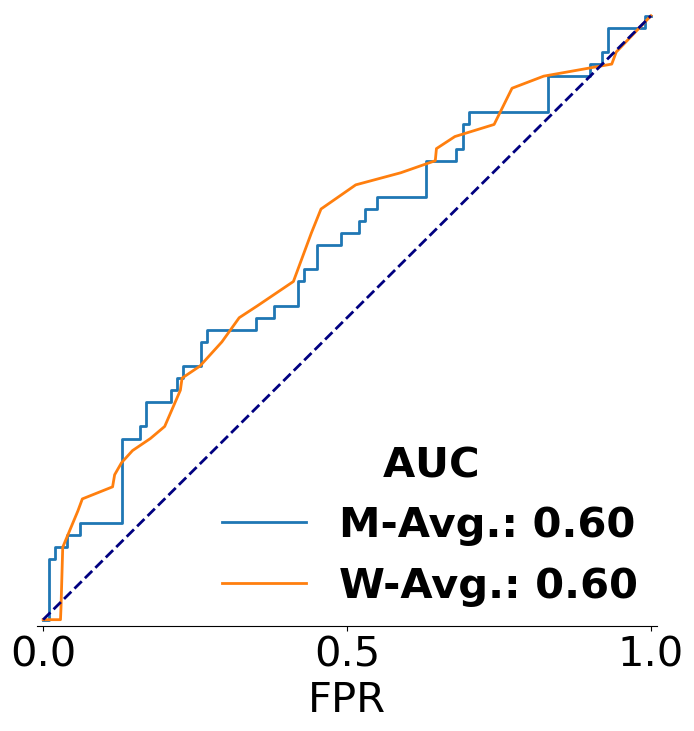

Macrophages 
 ['High' 'Low' 'Moderate']


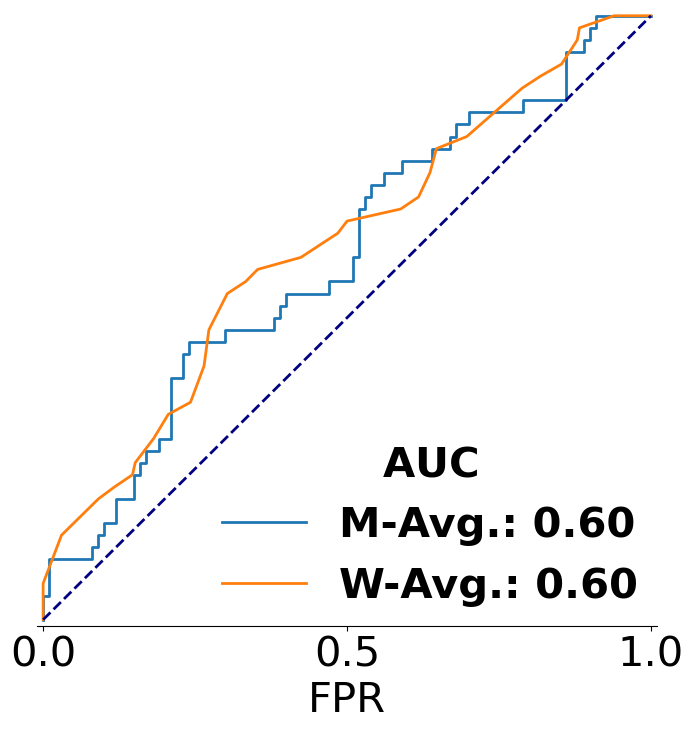

STAD
Homozygous in all three loci = 1 
 [0. 1.]


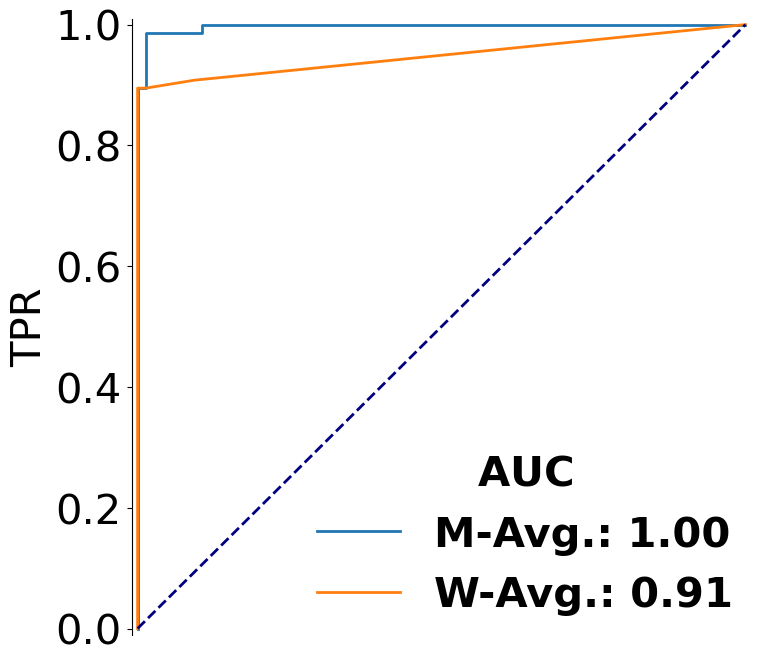

Eosinophils 
 ['Min' 'Not Min']


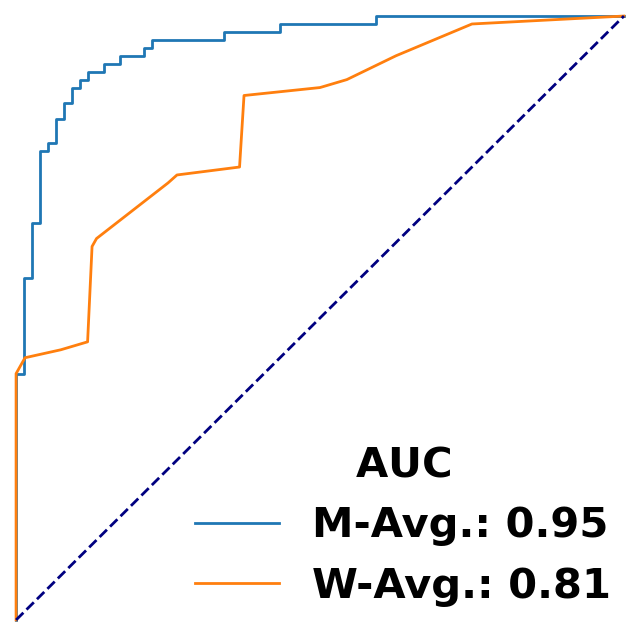

T Cells CD4 Naive 
 ['Min' 'Not Min']


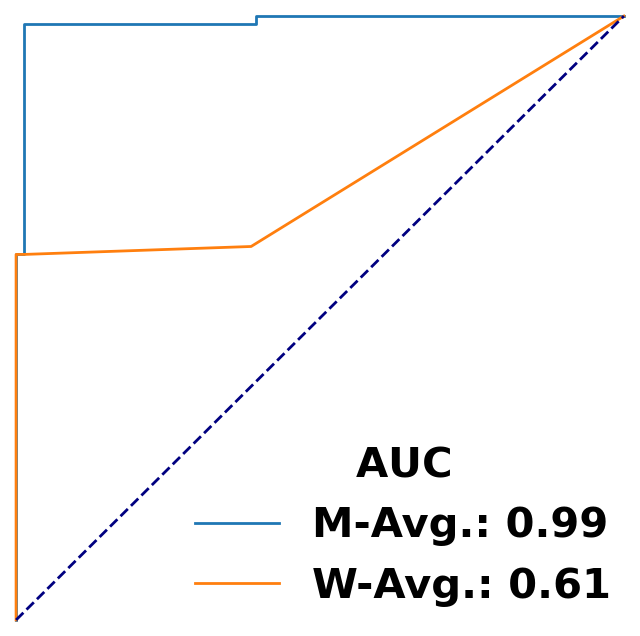

homo HLA-C =1 
 [0. 1.]


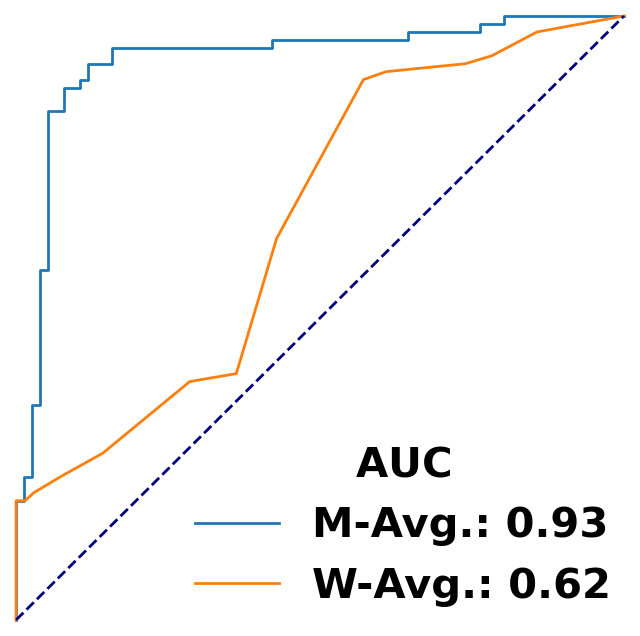

homo HLA-A =1 
 [0. 1.]


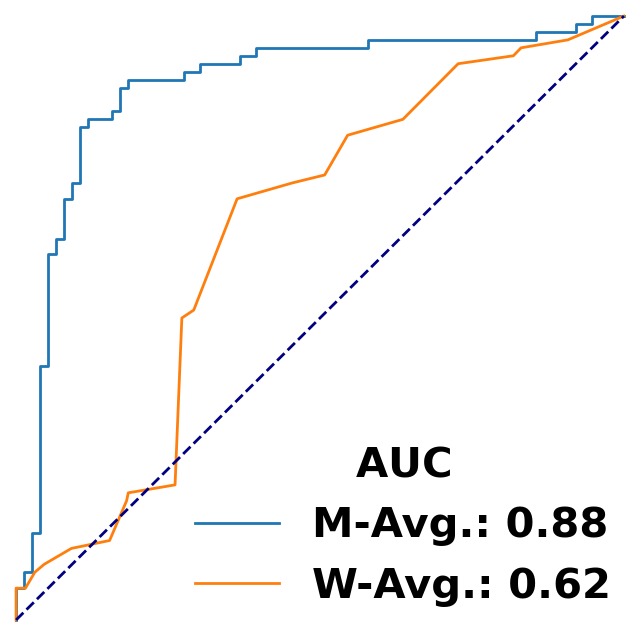

T Cells Follicular Helper 
 ['High' 'Low' 'Moderate']


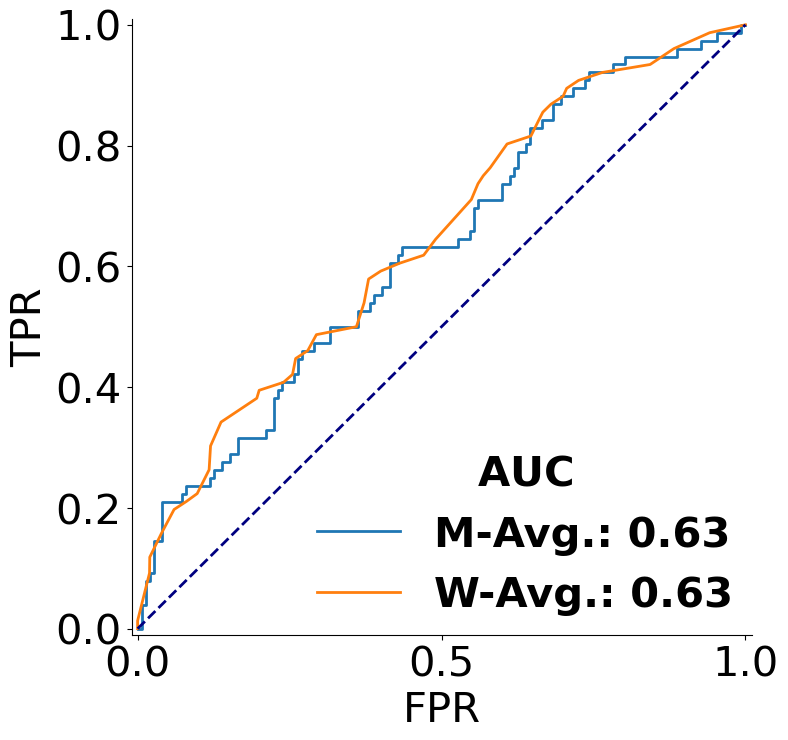

Th2 Cells 
 ['High' 'Low' 'Moderate']


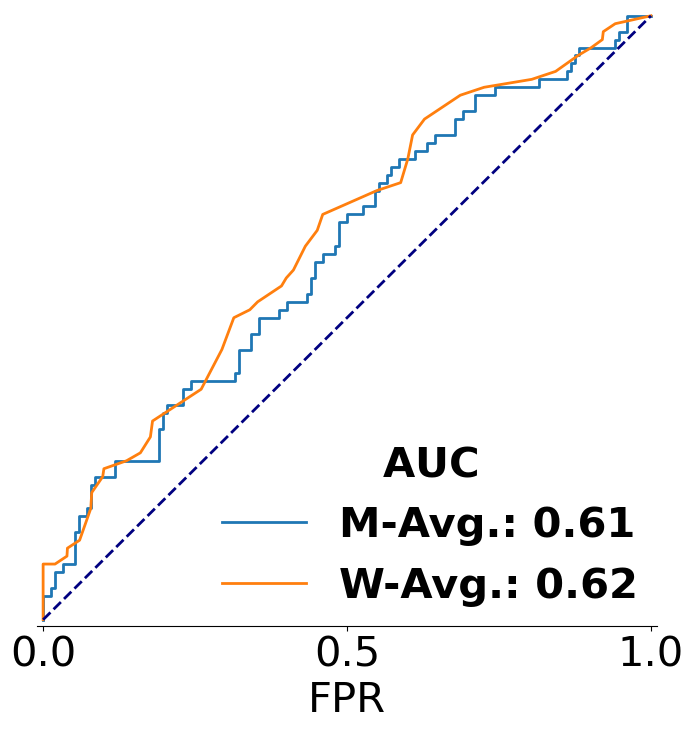

TCR Richness 
 ['High' 'Low' 'Moderate']


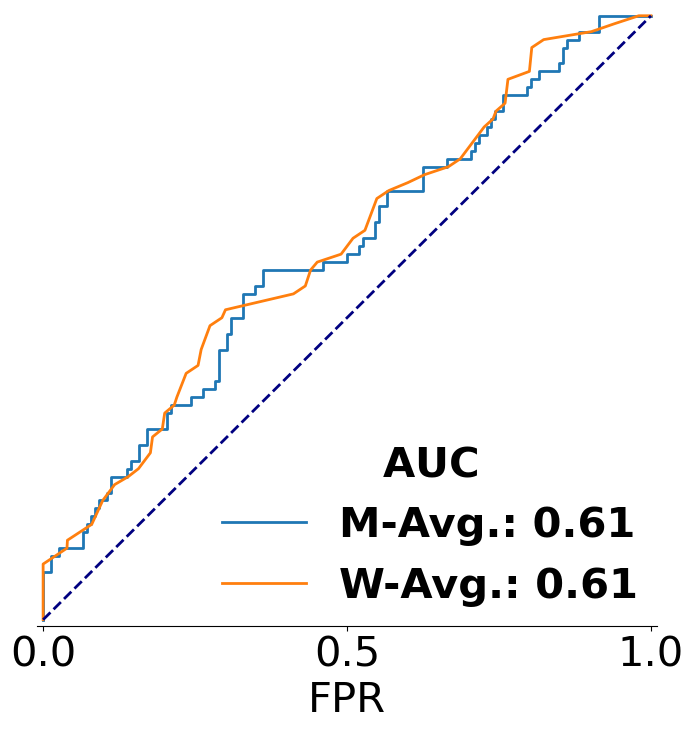

BCR Shannon 
 ['High' 'Low' 'Moderate']


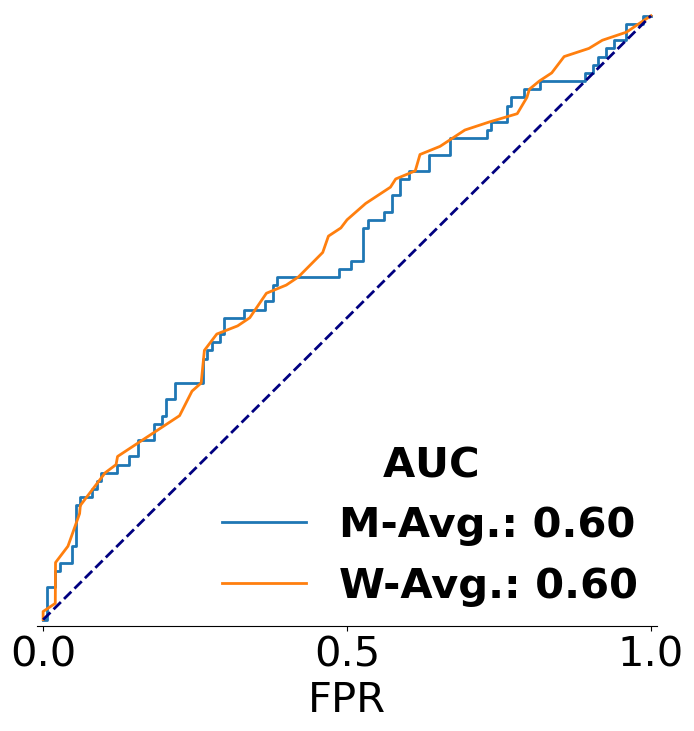

Lymphocytes 
 ['High' 'Low' 'Moderate']


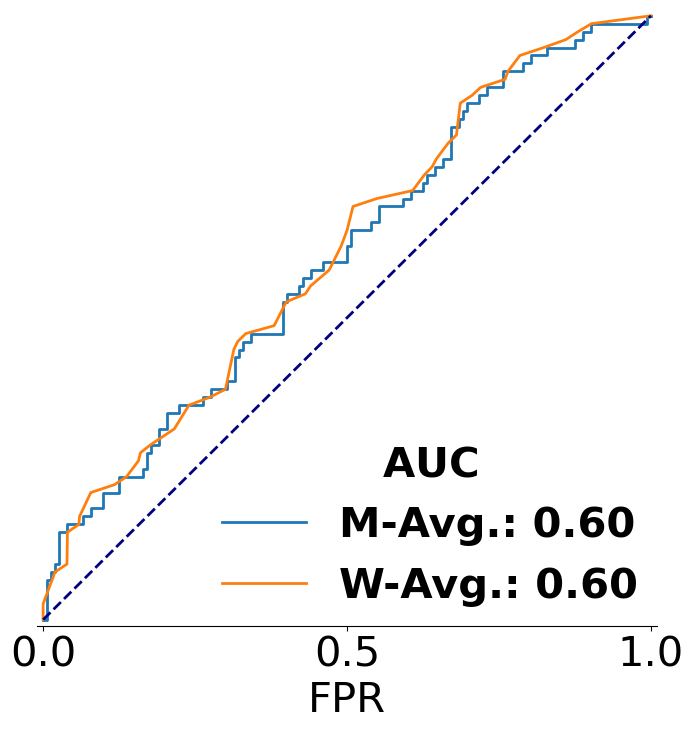

In [44]:
for CANCER in ['COAD', 'STAD']:
    print('=================================')
    print(CANCER)
    print('=================================')
    roc_curve_all(disease=CANCER, plot_axis='default')

---

### For website "x1y1"

T Cells CD4 Naive 
 ['Min' 'Not Min']


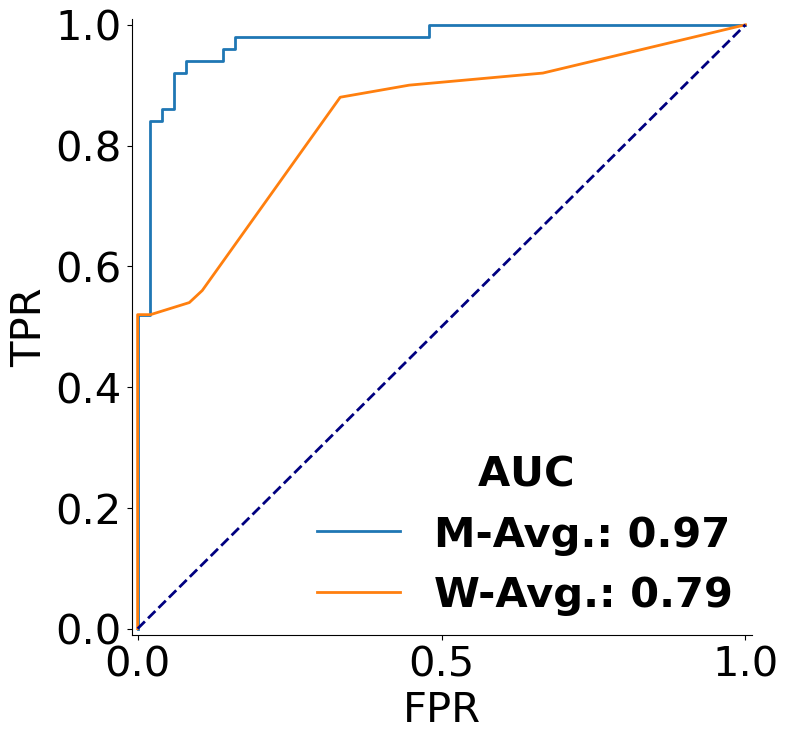

Homozygous in all three loci = 1 
 [0. 1.]


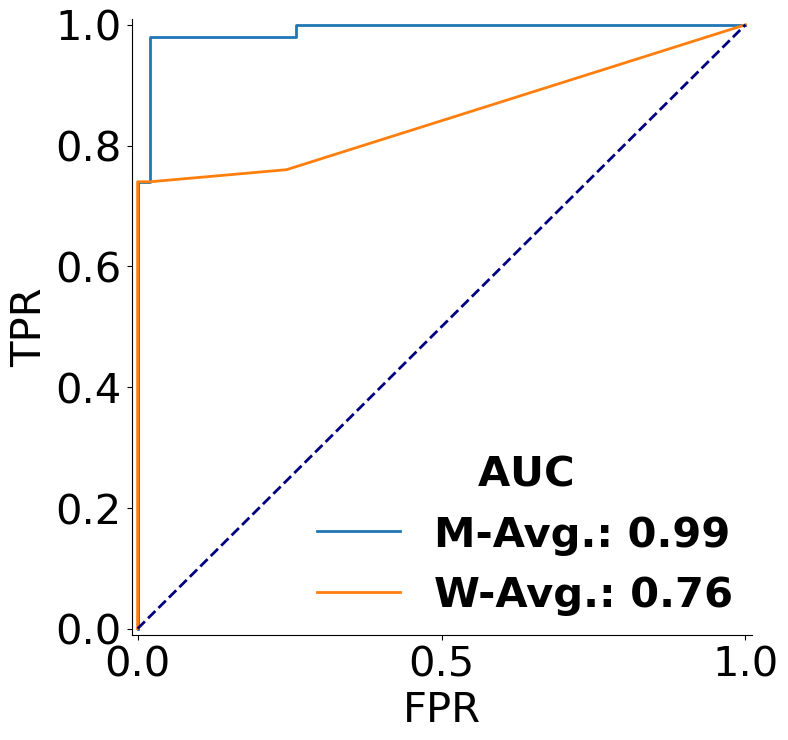

Immune Subtype 
 ['C1' 'C2' 'C4']


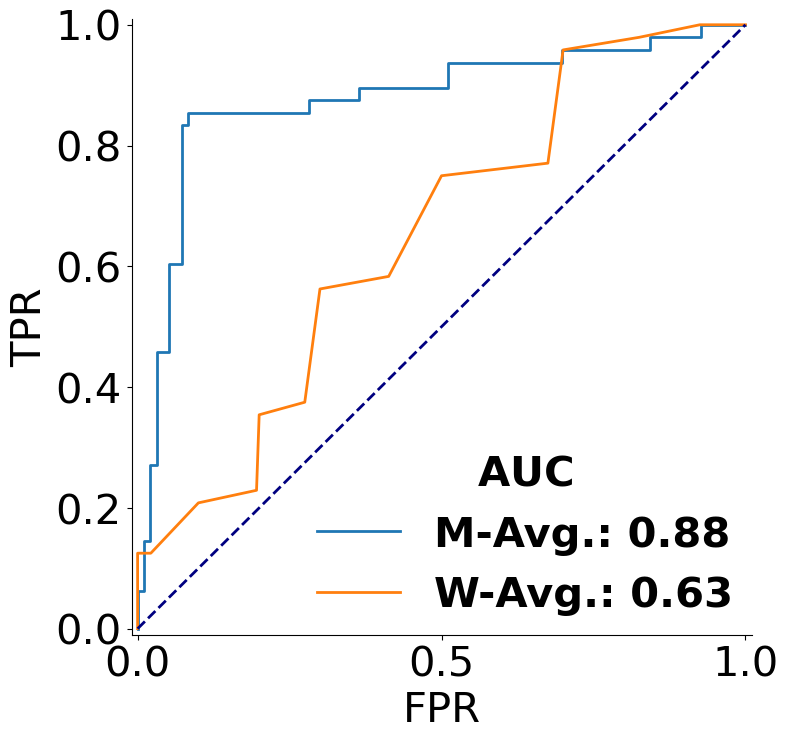

NK Cells Activated 
 ['High' 'Low']


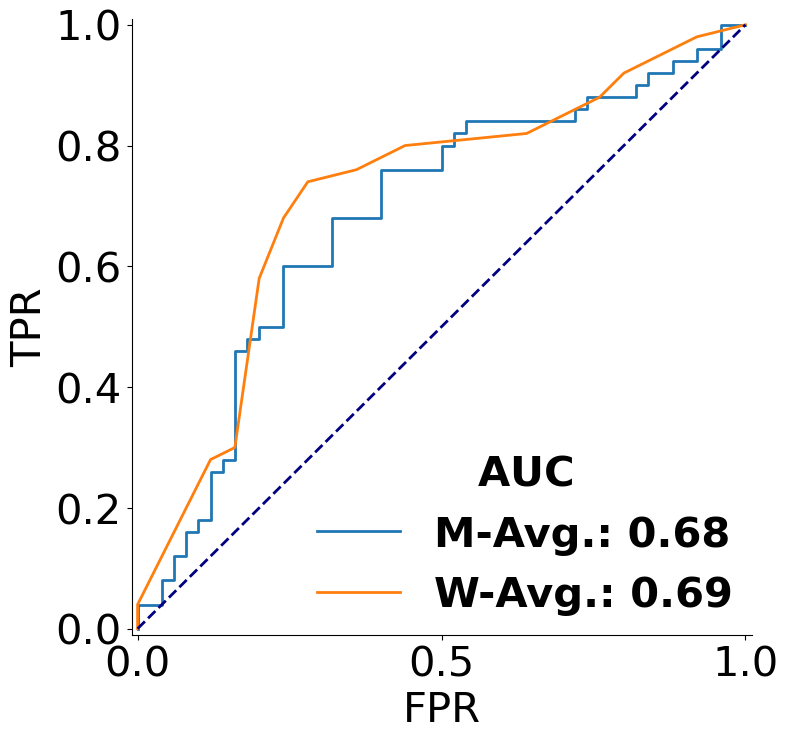

Neutrophils 
 ['Min' 'Not Min']


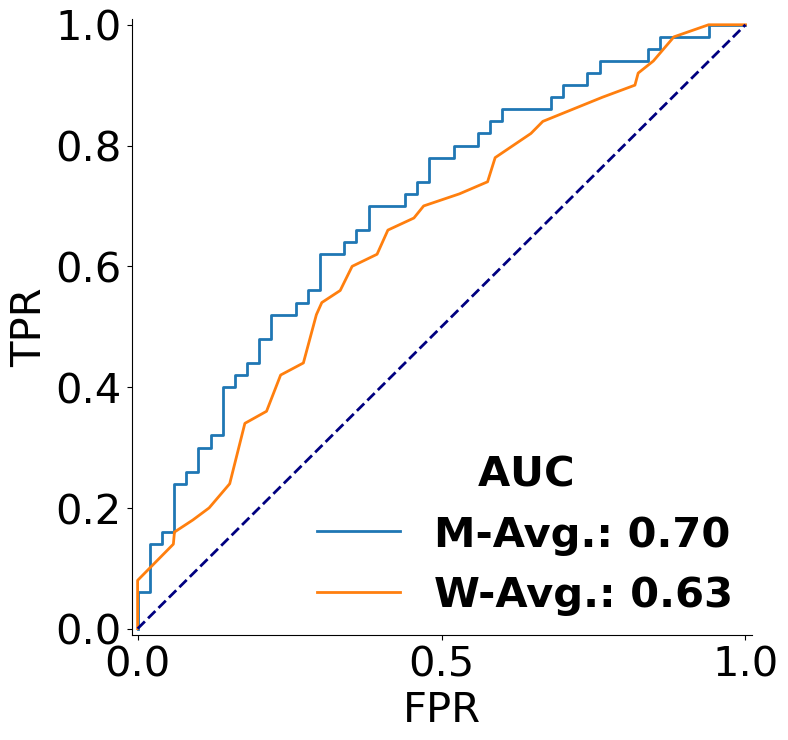

Th1 Cells 
 ['High' 'Low' 'Moderate']


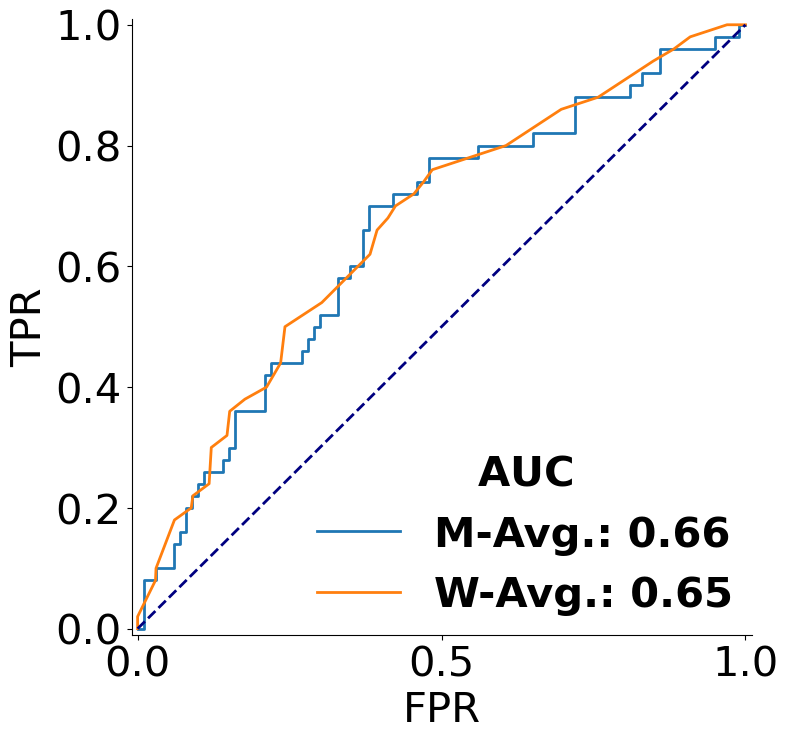

Macrophages M0 
 ['High' 'Low' 'Moderate']


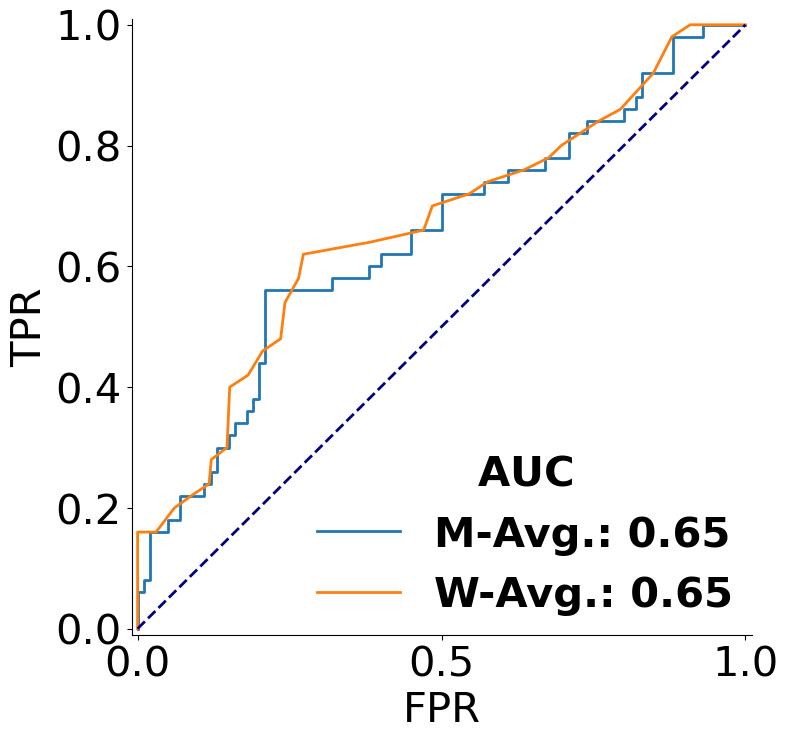

Dendritic Cells Activated 
 ['Min' 'Not Min']


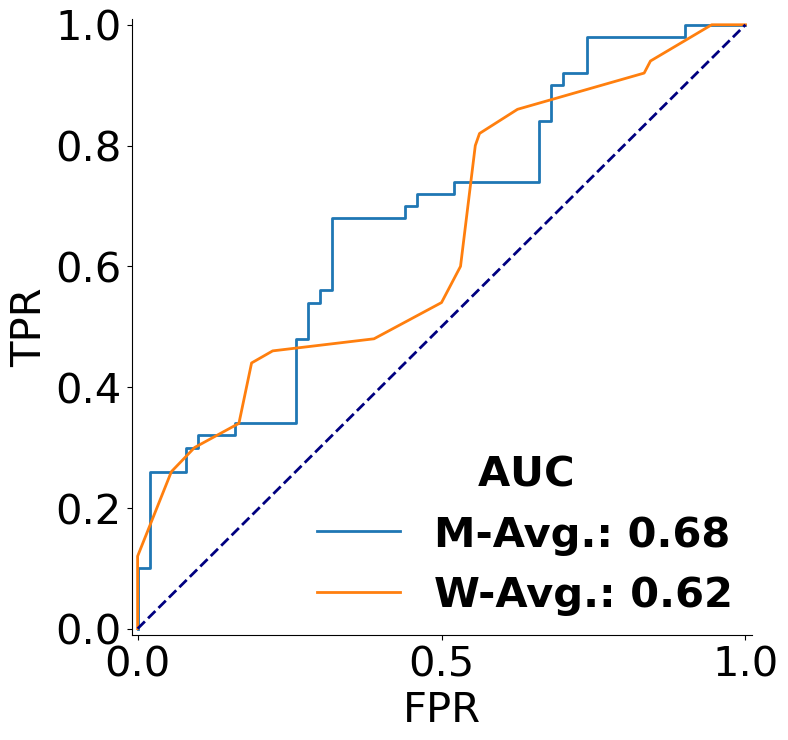

Dendritic Cells Resting 
 ['High' 'Low']


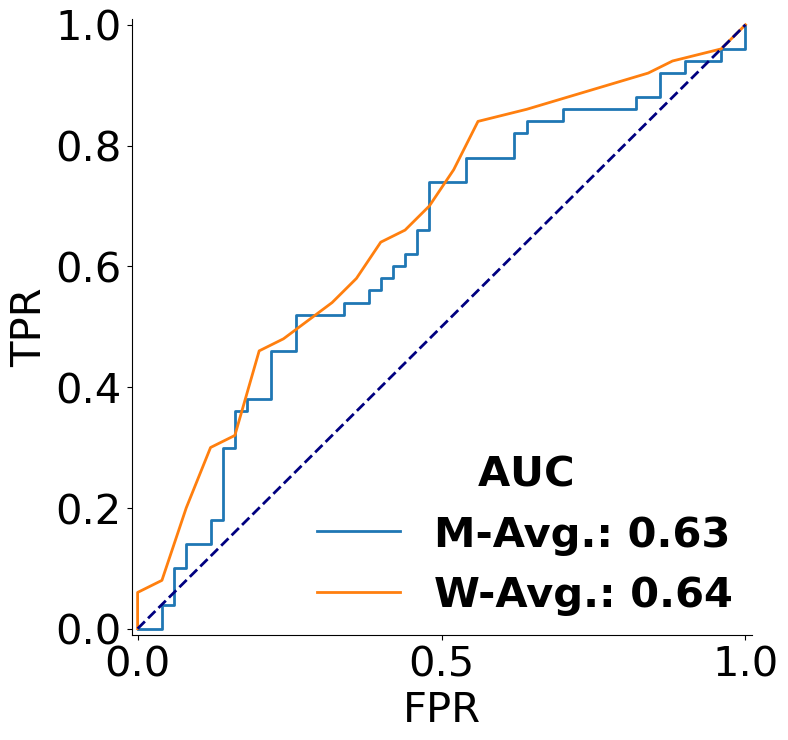

TGF-beta Response 
 ['High' 'Low' 'Moderate']


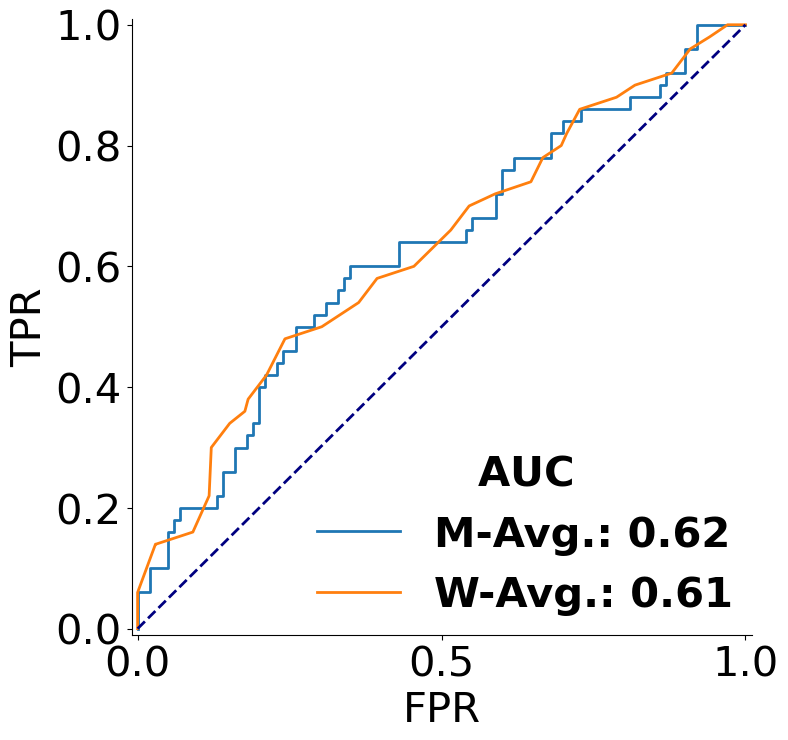

Leukocyte Fraction 
 ['High' 'Low' 'Moderate']


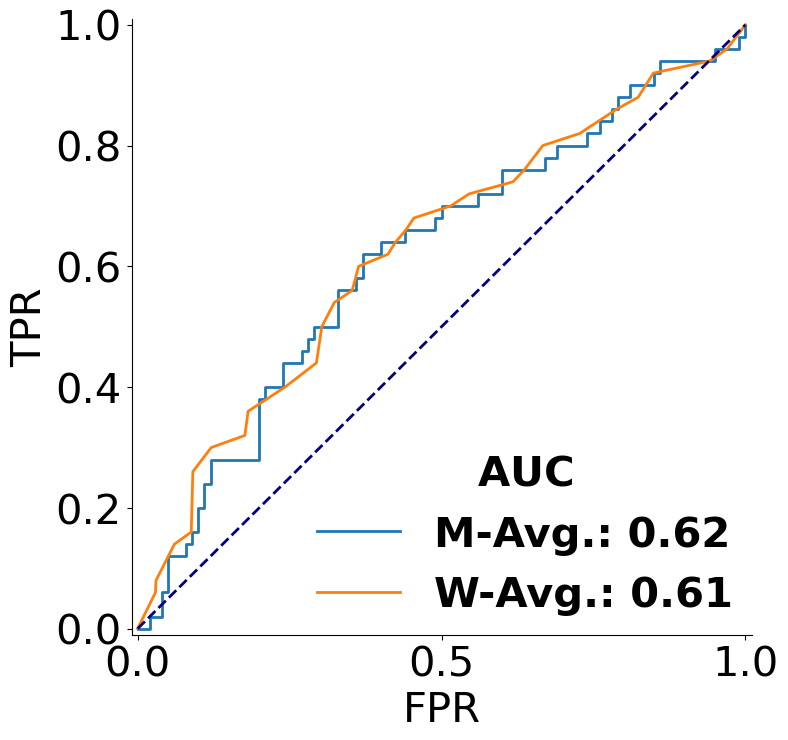

TCR Richness 
 ['High' 'Low' 'Moderate']


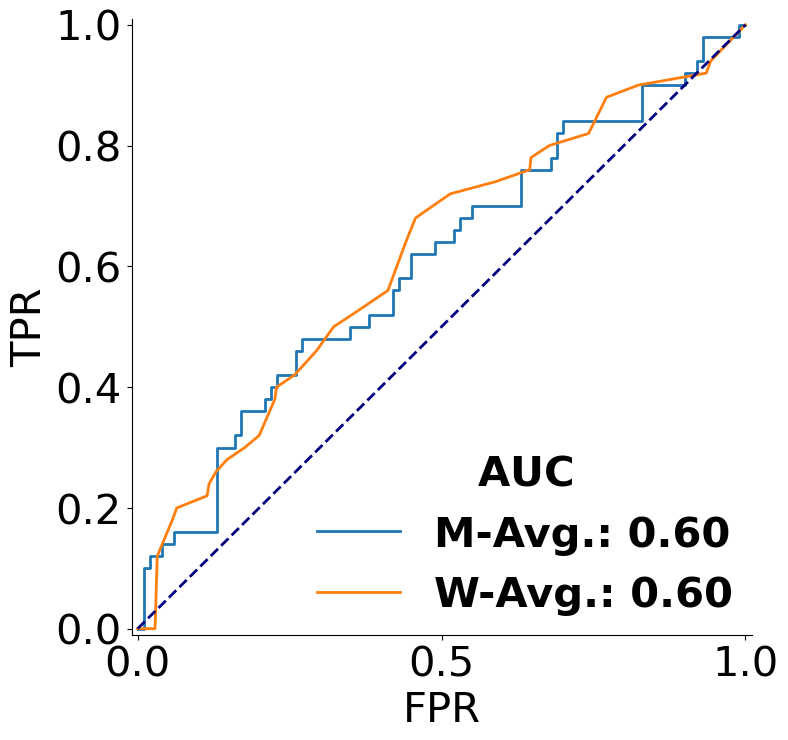

Macrophages 
 ['High' 'Low' 'Moderate']


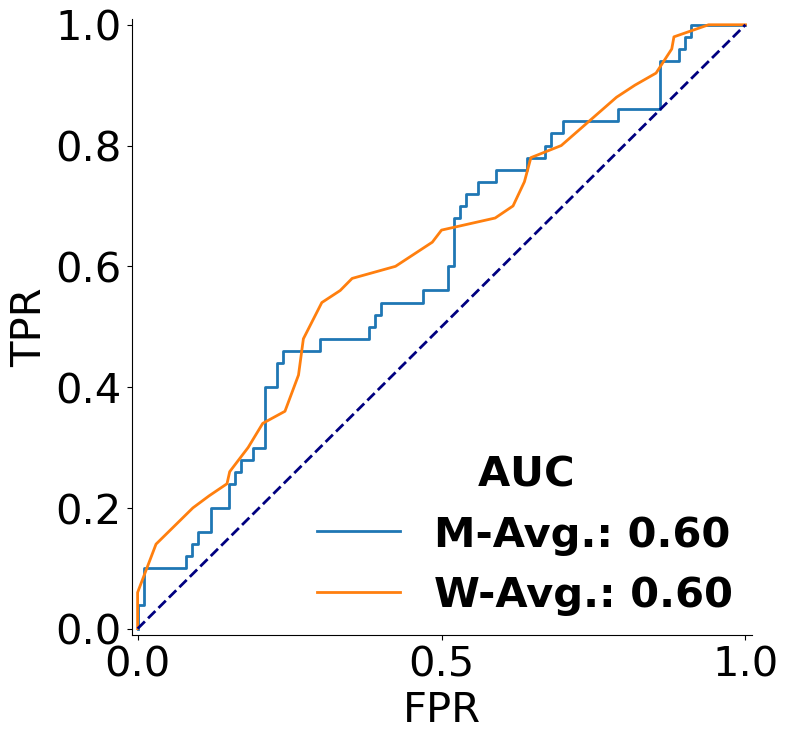

Homozygous in all three loci = 1 
 [0. 1.]


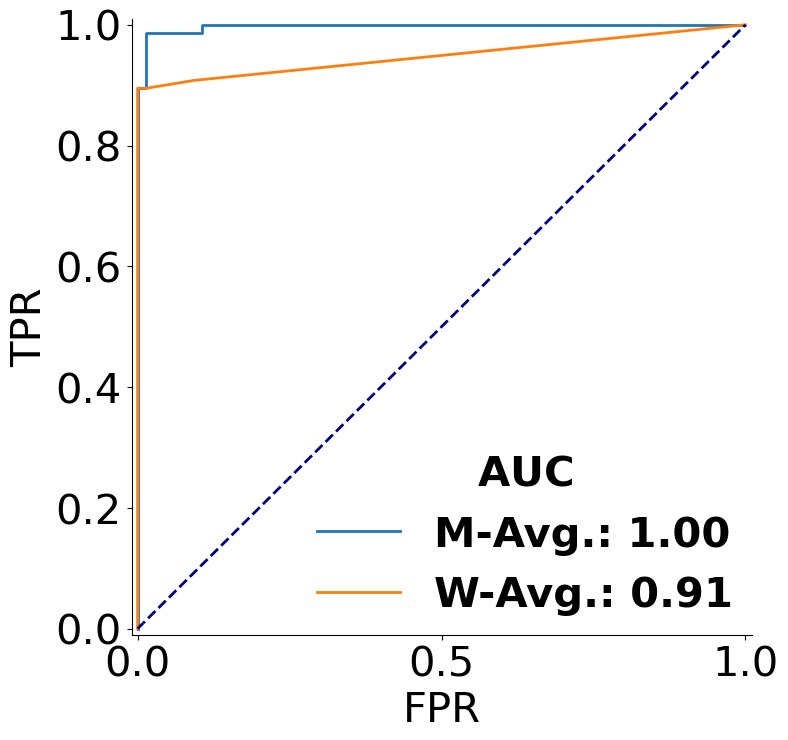

Eosinophils 
 ['Min' 'Not Min']


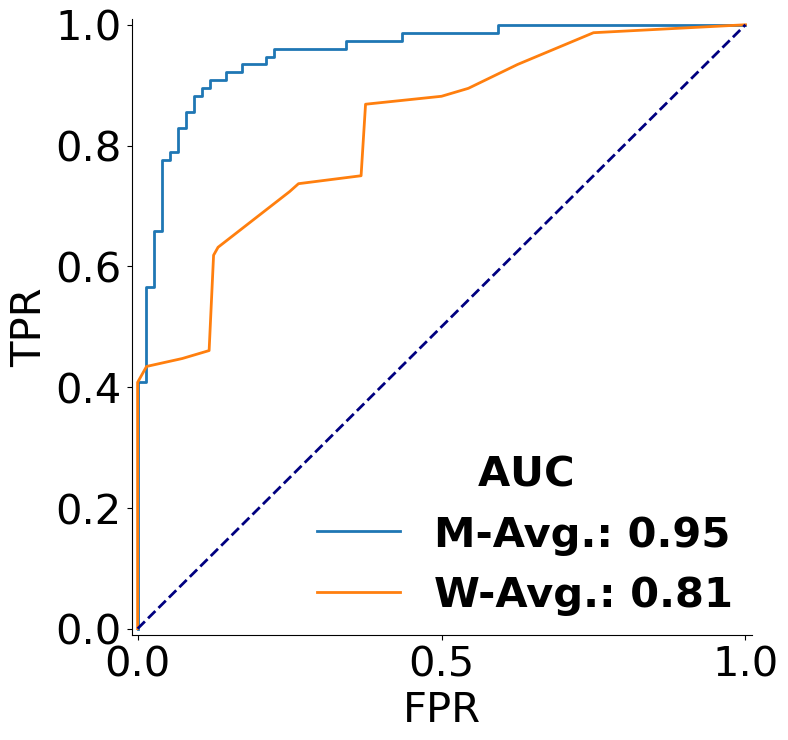

T Cells CD4 Naive 
 ['Min' 'Not Min']


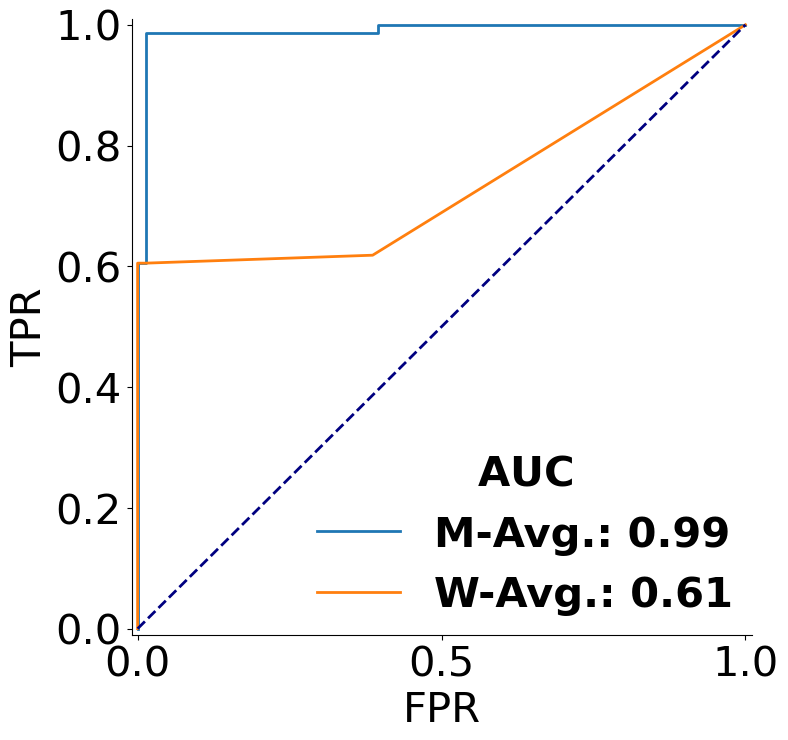

homo HLA-C =1 
 [0. 1.]


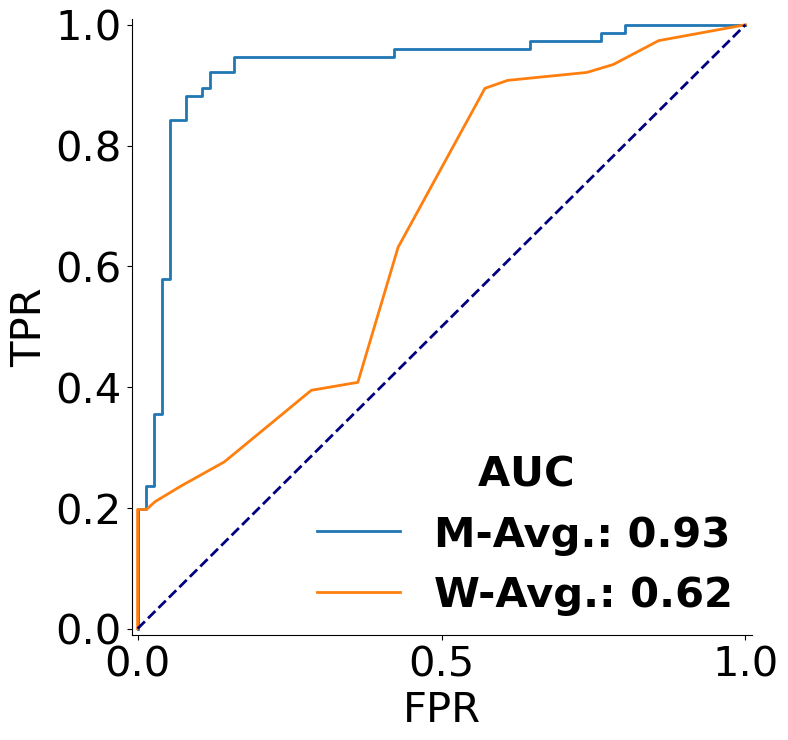

homo HLA-A =1 
 [0. 1.]


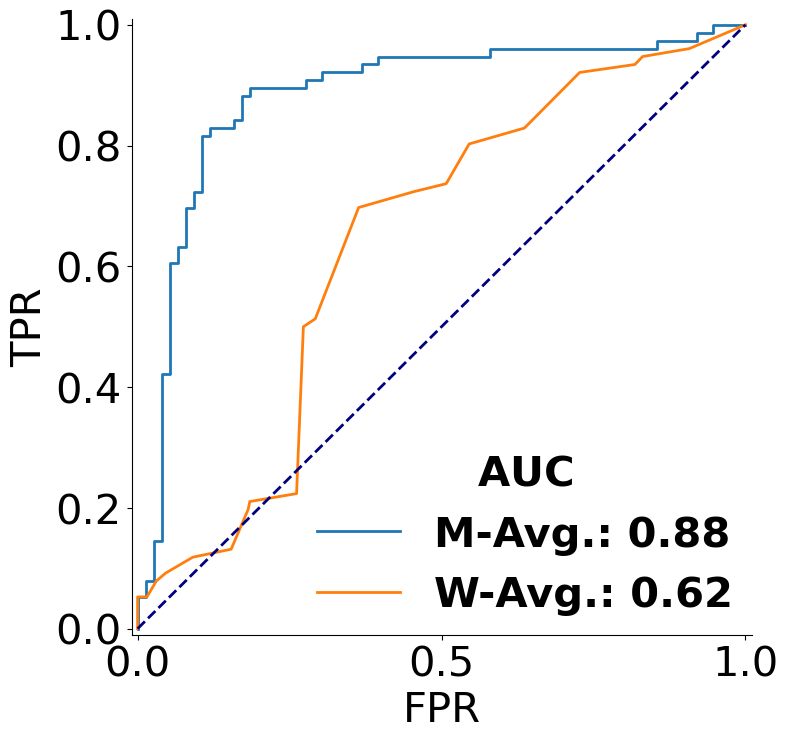

T Cells Follicular Helper 
 ['High' 'Low' 'Moderate']


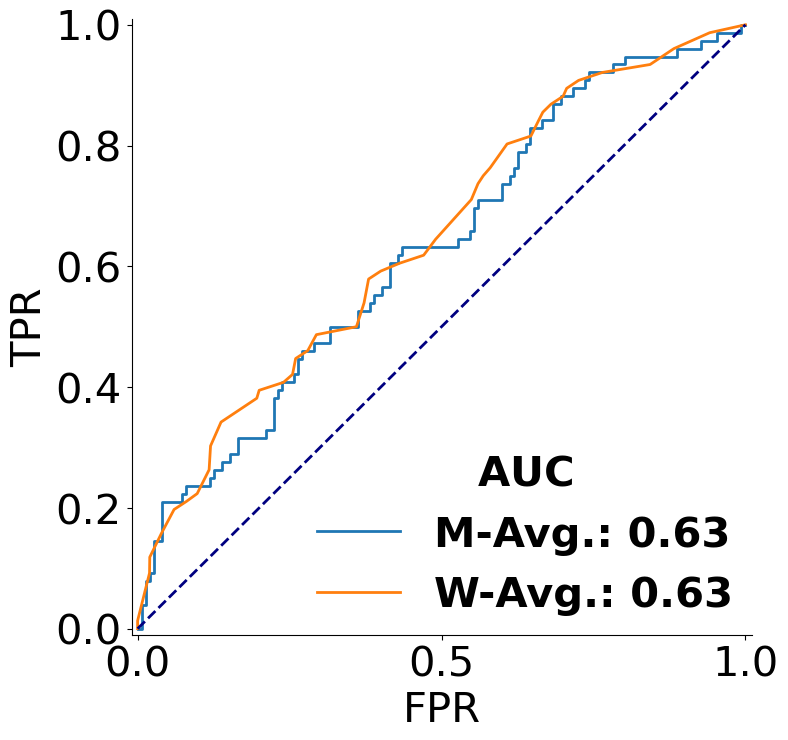

Th2 Cells 
 ['High' 'Low' 'Moderate']


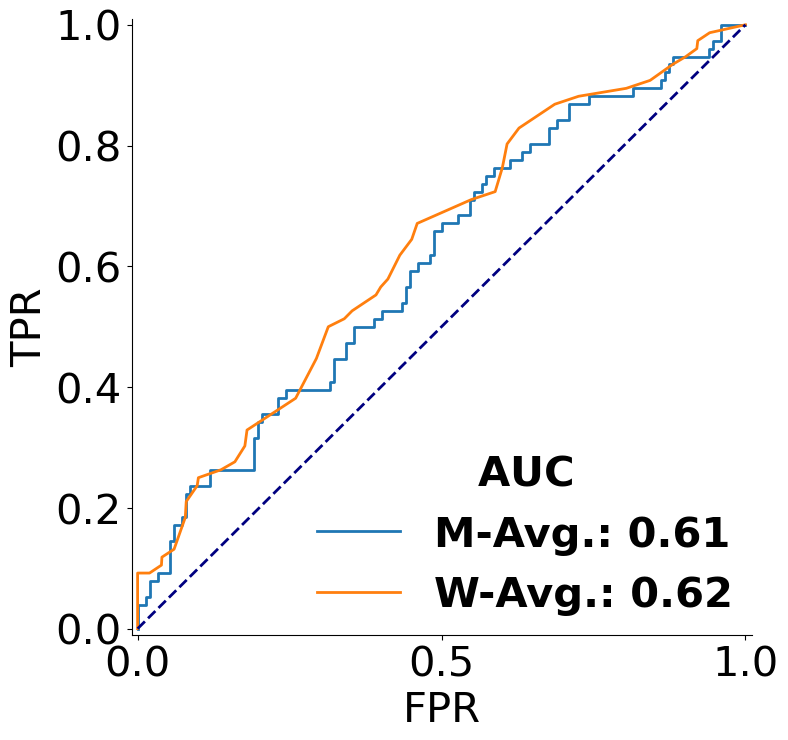

TCR Richness 
 ['High' 'Low' 'Moderate']


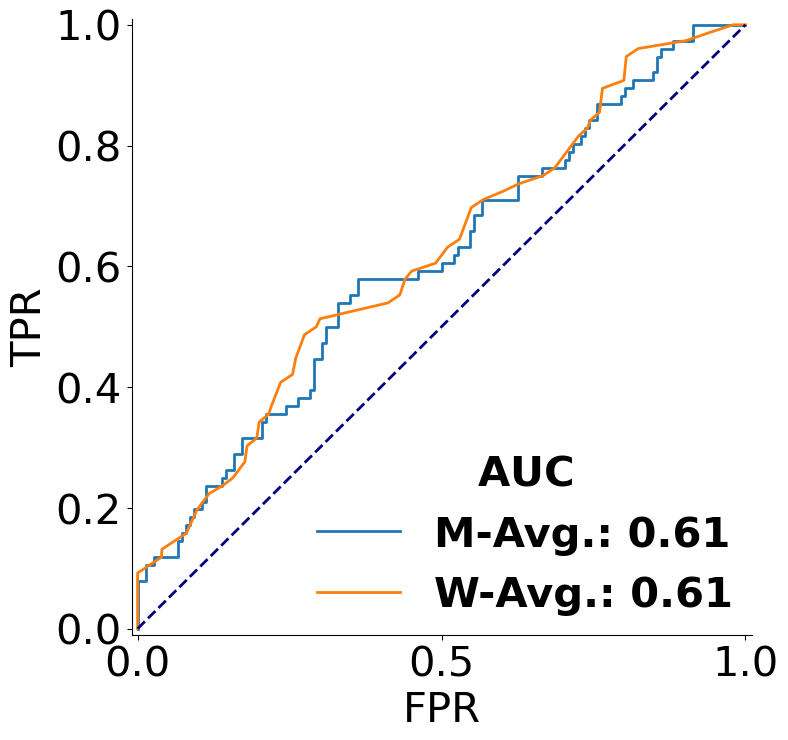

BCR Shannon 
 ['High' 'Low' 'Moderate']


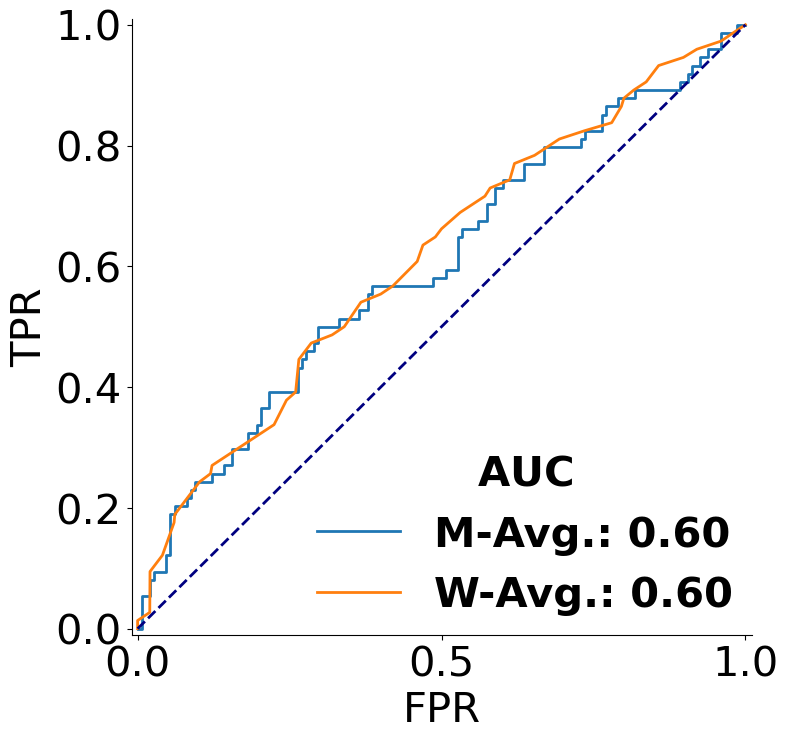

Lymphocytes 
 ['High' 'Low' 'Moderate']


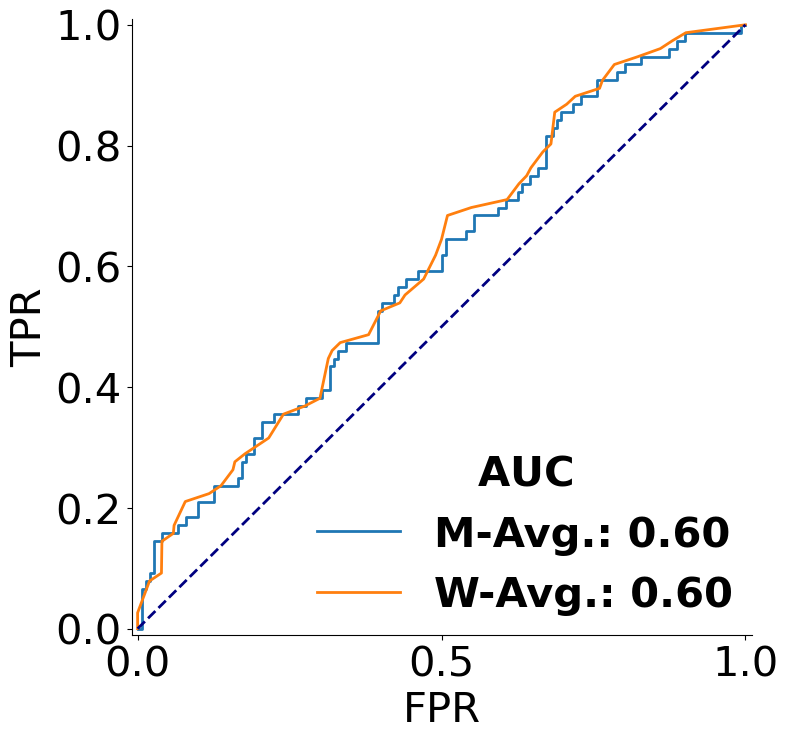

Homozygous in all three loci = 1 
 [0. 1.]


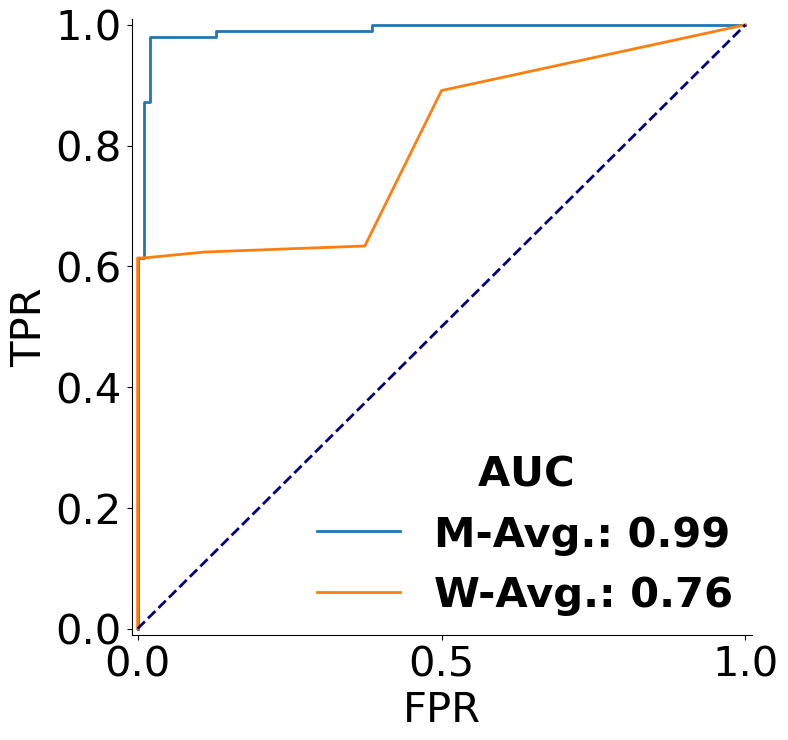

Eosinophils 
 ['Min' 'Not Min']


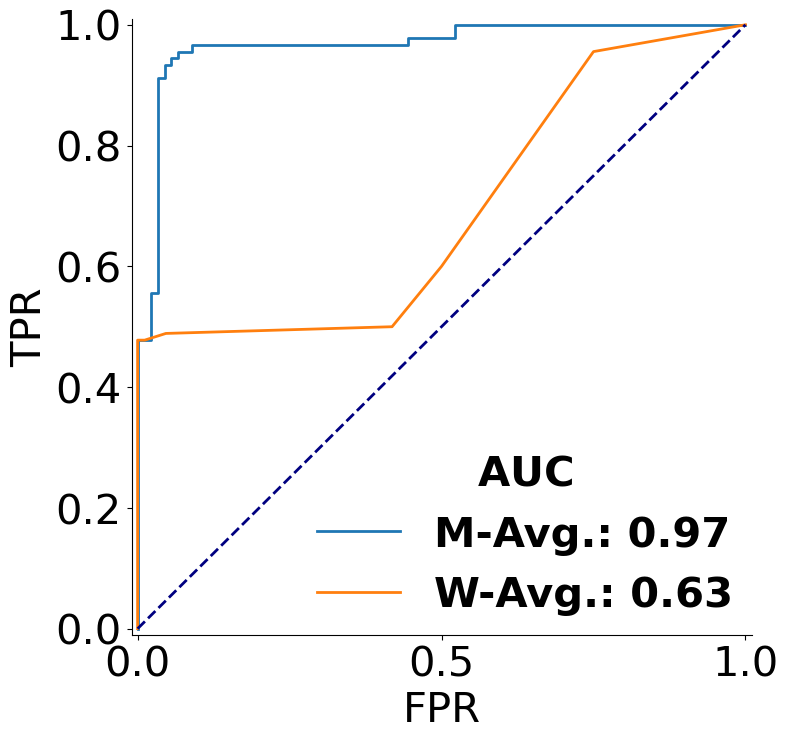

T Cells gamma delta 
 ['Min' 'Not Min']


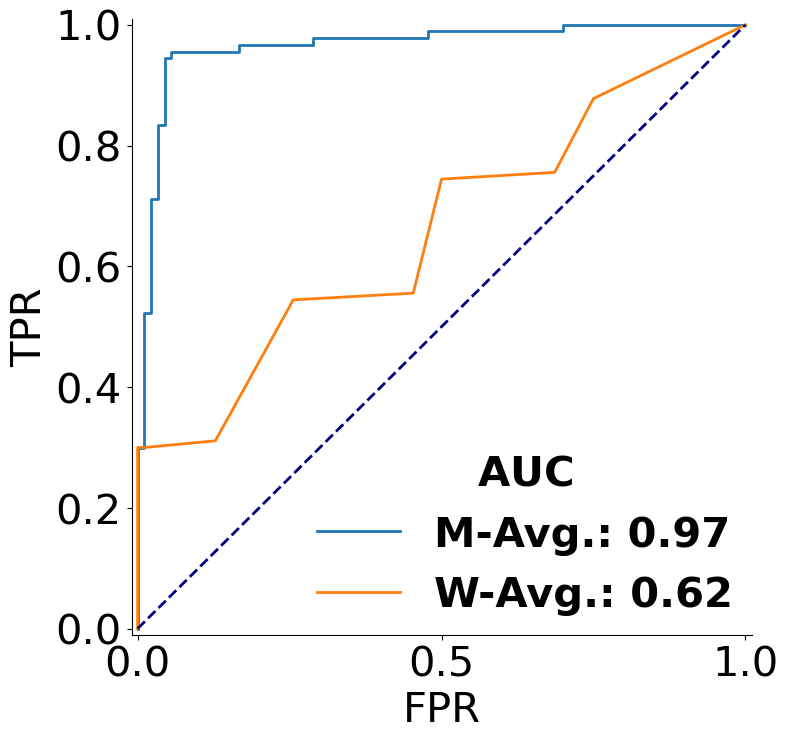

Homozygous in at least one locus = 1 
 [0. 1.]


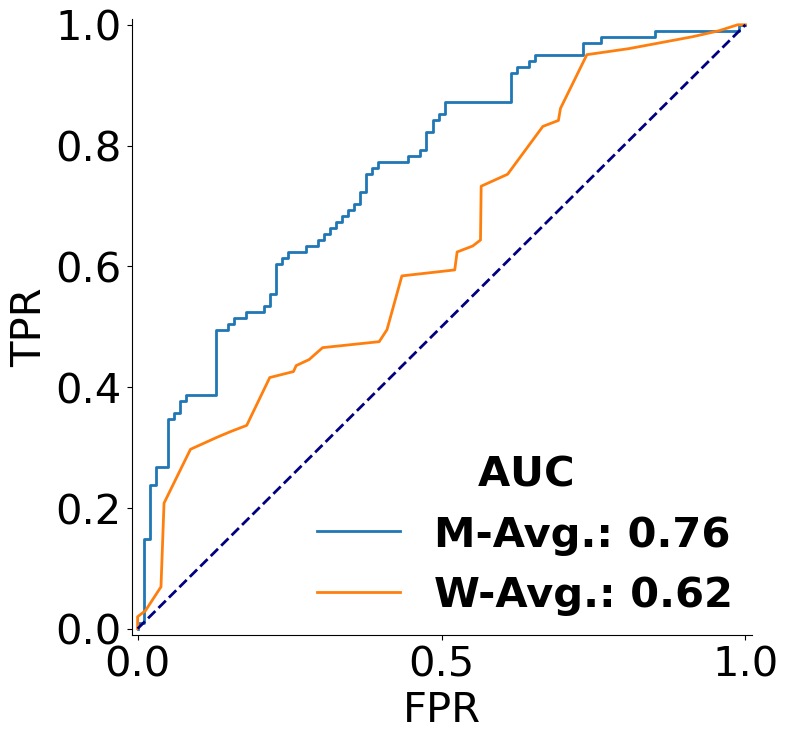

Mast Cells Activated 
 ['Min' 'Not Min']


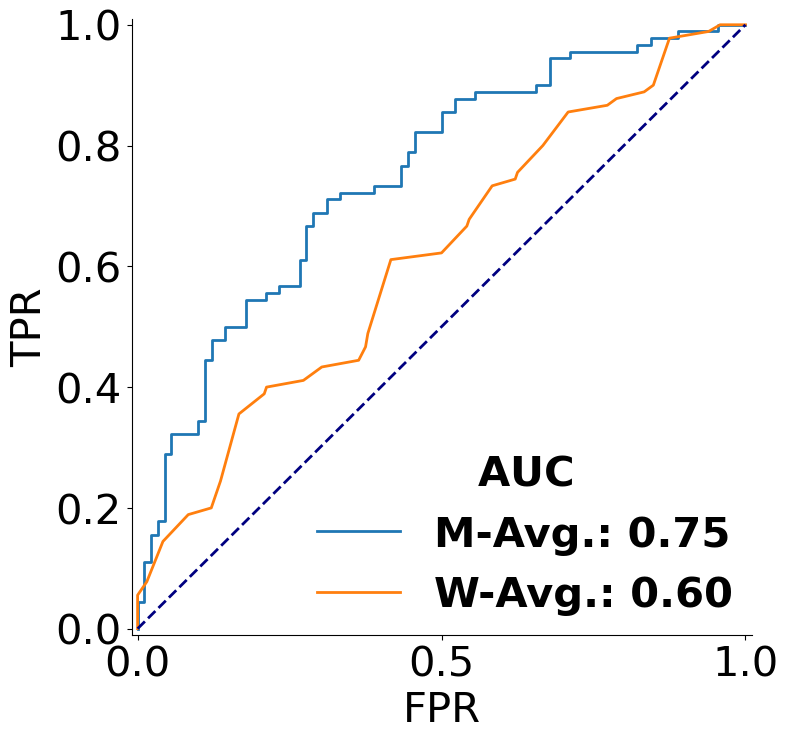

B Cells Memory 
 ['Min' 'Not Min']


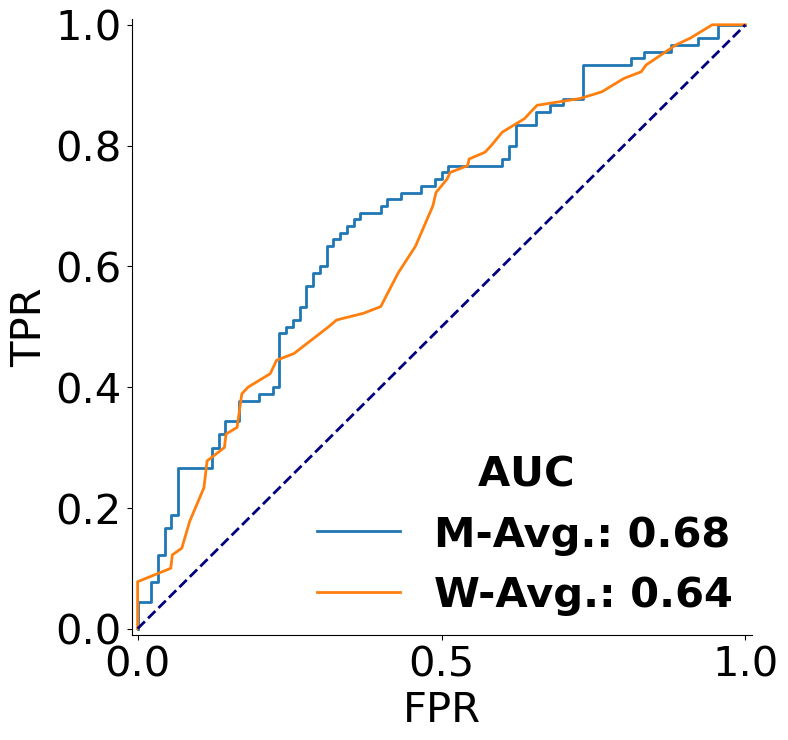

T Cells gamma delta 
 ['Min' 'Not Min']


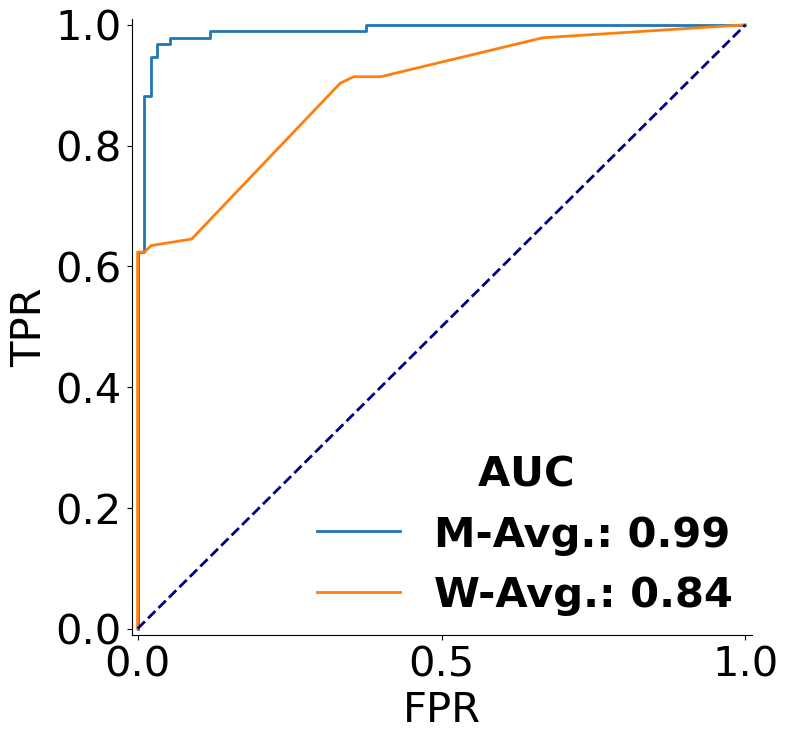

homo HLA-C =1 
 [0. 1.]


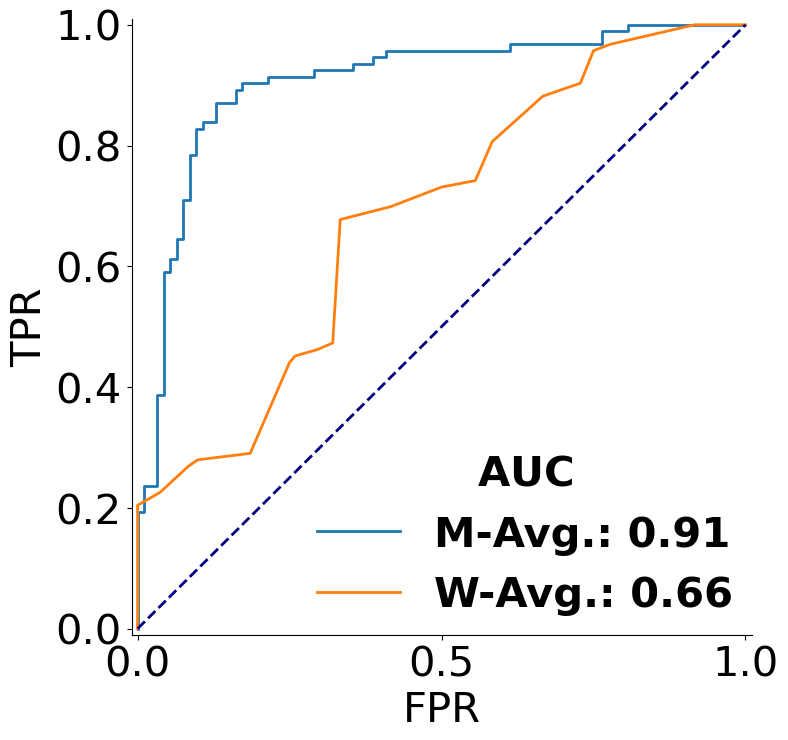

T Cells CD4 Naive 
 ['Min' 'Not Min']


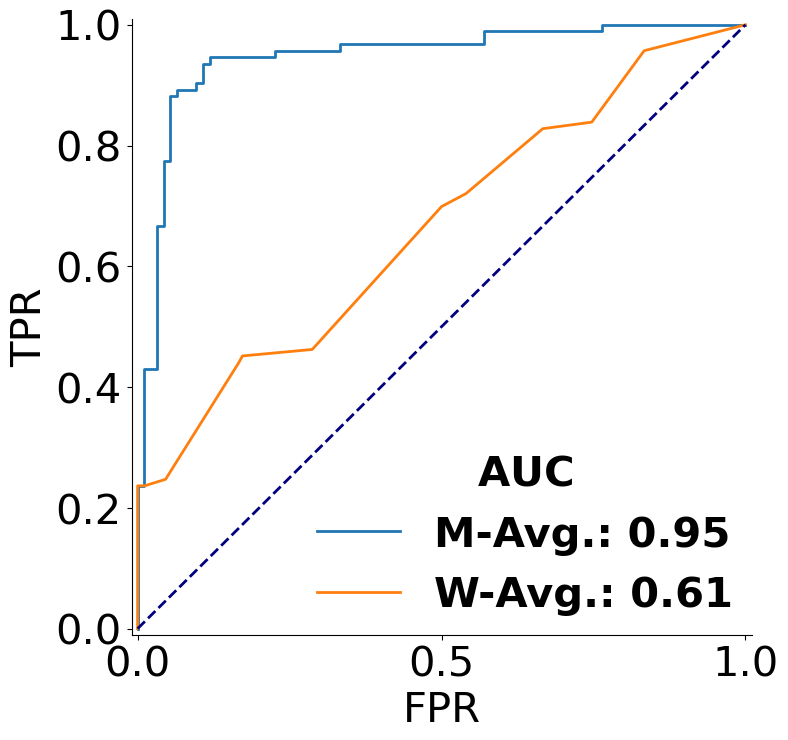

TCR Richness 
 ['High' 'Low' 'Moderate']


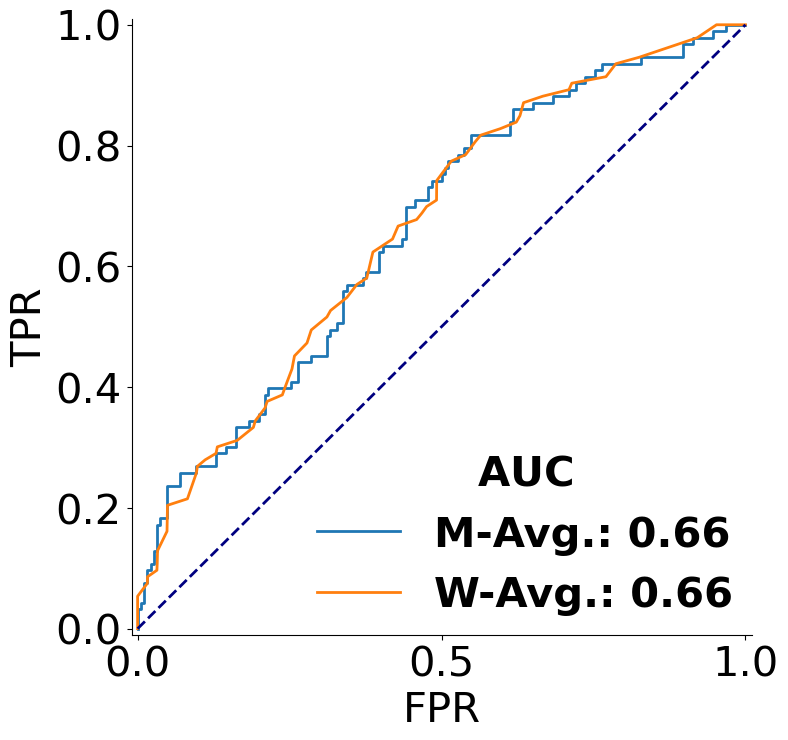

Macrophages 
 ['High' 'Low' 'Moderate']


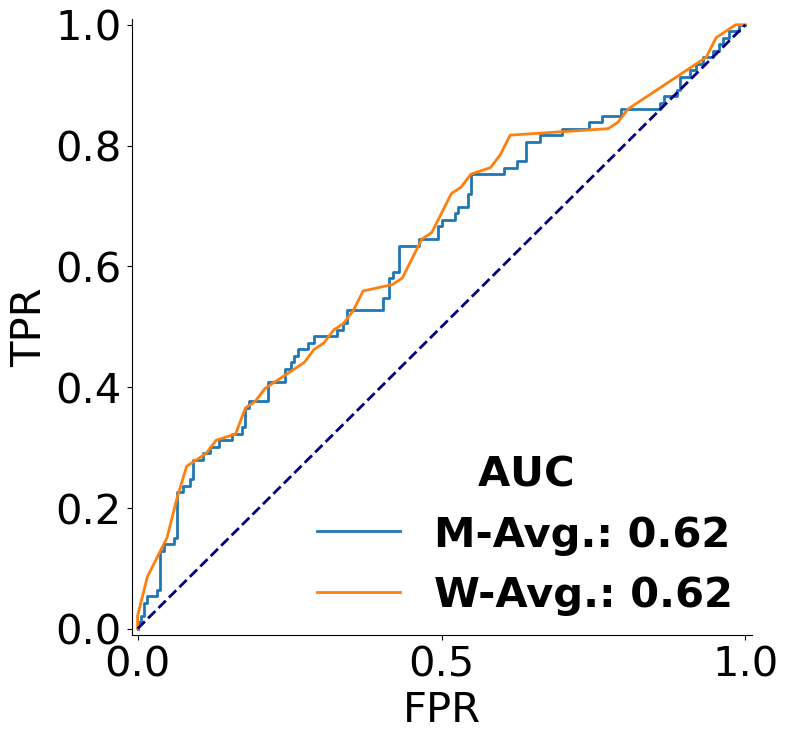

Th1 Cells 
 ['High' 'Low' 'Moderate']


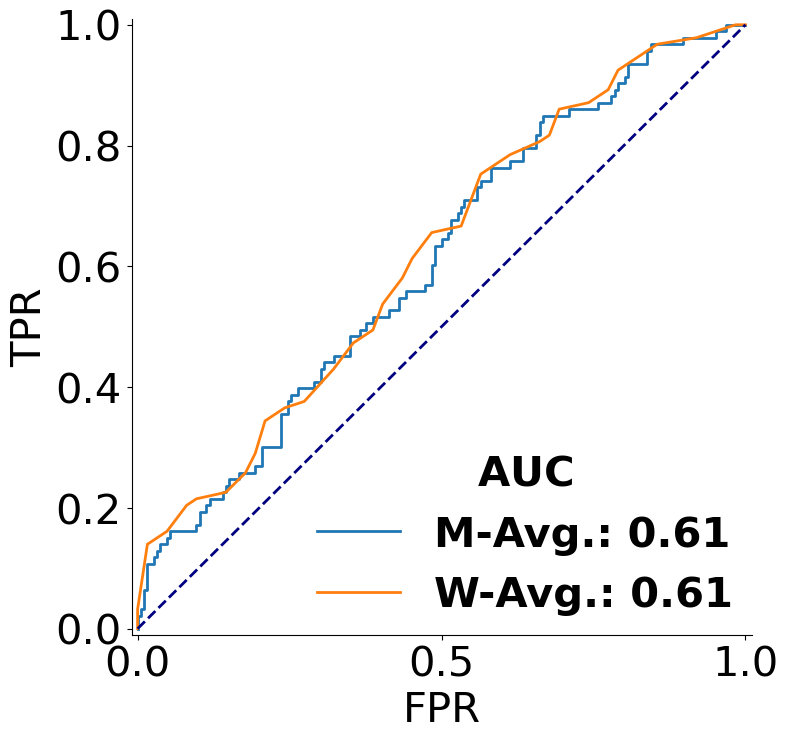

In [45]:
roc_curve_all(disease='COAD', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')
roc_curve_all(disease='STAD', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')
roc_curve_all(disease='LUAD', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')
roc_curve_all(disease='LUSC', fig_save_folder='./figures/web_ROC', plot_axis='x1y1', save_format='png')

## Heatmap

In [16]:
def sort_influence(disease, save_folder='./', decreasing=True, covariate_list=None):
    with open(os.path.join(save_folder, f'results/LRP/{disease}/lrp_result_dict.pkl'), "rb") as f:
        lrp_result_dict = CPU_Unpickler(f).load()
    influence = lrp_result_dict['influence_by_microbe_all']
    row_names = lrp_result_dict['y_col_names'] if covariate_list is None else covariate_list
    column_names = pd.read_pickle(os.path.join(save_folder, 
                                               f'data/processed data/{disease}_microbiome_clean.pkl')).columns
    column_names = np.array([name.split('-')[0] for name in column_names])
    ### Sorted by col sum
    ascending_sort_idx_col = np.argsort(np.sum(influence, axis=0))
    sort_idx_col = ascending_sort_idx_col[::-1] if decreasing else ascending_sort_idx_col
    ### Sorted row by AUC scores
    sorted_auc_df = sorted_auc(disease, print_disease_name=False)
    sort_idx_row = np.array([np.where(rn == row_names)[0][0] for rn in sorted_auc_df['Covariate']])
    sorted_influence_df = pd.DataFrame(influence[sort_idx_row,:][:, sort_idx_col], 
                                columns = column_names[sort_idx_col], 
                                index = sorted_auc_df['Covariate'].values)
    return sorted_influence_df

In [98]:
def heatmap_influence(
    disease,
    influence_df,
    top_col_pct=0.05,
    plot=True,
    covariate_subset=None,
    cmap="Blues",
    cbar=True,
    cmax=None,
    taxa_names=True,
    feature_names=True,
    fontsize=16,
    row_label_fontsize=None,
    col_label_fontsize=None,
    anno_label_fontsize=None,
    colorbar_tick_fontsize=None,
    font_scale=2.5,
    linewidths=0.,
    horizontal=True,
    save=False,
    fig_save_folder='./figures',
    add_ecology_bar=False,
    ecology_file="../data/bacdive_genus_ecology_labels.csv"
):

    import os
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap, BoundaryNorm
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    genus_name = list(influence_df.columns)
    nona_idx = np.where(np.array(genus_name) != '')[0]
    genus_name_nona = np.array(genus_name)[nona_idx]

    influence_df_genus_lvl = influence_df.iloc[:, nona_idx]
    influence_df_genus_lvl.columns = list(genus_name_nona)

    n_col_selected = np.round(influence_df_genus_lvl.shape[1] * top_col_pct).astype(int)
    n_col_selected = max(n_col_selected, 1)

    if covariate_subset is None:
        row_subset = influence_df_genus_lvl.index
    else:
        row_subset = covariate_subset

    influence_df_genus_lvl_marker = influence_df_genus_lvl.loc[
        row_subset, influence_df_genus_lvl.columns[:n_col_selected]
    ]

    if top_col_pct == 1.:
        influence_df_genus_lvl_marker.to_csv(f'./results/LRP/{disease}/sorted_influence_df.csv')
    else:
        influence_df_genus_lvl_marker.to_csv(
            f'./results/LRP/{disease}/sorted_influence_df_pct{str(int(top_col_pct*100))}.csv'
        )

    if plot:
        sns.set(font_scale=font_scale)

        if horizontal:
            figheight = len(row_subset) * 2 - 2
            figwidth = n_col_selected * 2
            fig, ax = plt.subplots(figsize=(figwidth, figheight))

            hm = sns.heatmap(
                influence_df_genus_lvl_marker,
                linewidths=linewidths,
                cbar=cbar,
                cbar_kws={"pad": 0.01},
                cmap=cmap,
                vmin=0,
                vmax=cmax,
                ax=ax
            )

            row_fs = row_label_fontsize if row_label_fontsize is not None else fontsize
            col_fs = col_label_fontsize if col_label_fontsize is not None else fontsize
            cbar_fs = colorbar_tick_fontsize if colorbar_tick_fontsize is not None else max(10, int(fontsize * 0.6))

            if taxa_names:
                hm.set_xticklabels(
                    hm.get_xticklabels(),
                    rotation=45,
                    ha='left',
                    rotation_mode='anchor',
                    fontsize=col_fs
                )
            else:
                hm.set_xticklabels([])

            if feature_names:
                hm.set_yticklabels(
                    hm.get_yticklabels(),
                    fontsize=row_fs,
                    rotation=0,
                    ha='right'
                )
            else:
                hm.set_yticklabels([])

            ax.tick_params(top=False, labelbottom=False, labeltop=True)

            if cbar:
                cb = hm.collections[0].colorbar
                cb.ax.tick_params(labelsize=cbar_fs)

        else:
            label_display_map = {
                "highly_likely_environmental": "Highly likely environmental",
                "could_be_environmental": "Could be environmental",
                "highly_likely_host_associated": "Highly likely host-associated",
                "likely_host_associated": "Likely host-associated",
                "mixed_or_uncertain": "Mixed or uncertain",
                "no_data": "No BacDive data"
            }

            label_abbrev_map = {
                "Highly likely environmental": "HE",
                "Could be environmental": "CE",
                "Highly likely host-associated": "HH",
                "Likely host-associated": "LH",
                "Mixed or uncertain": "MU",
                "No BacDive data": "NA"
            }

            label_color_map = {
                "Highly likely environmental": "#f8d7da",
                "Could be environmental": "#fde2c8",
                "Highly likely host-associated": "#8fd19e",
                "Likely host-associated": "#dff3e3",
                "Mixed or uncertain": "#e9ecef",
                "No BacDive data": "#f5f5f5"
            }

            label_text_color_map = {
                "Highly likely environmental": "#721c24",
                "Could be environmental": "#8a4b08",
                "Highly likely host-associated": "#0f5132",
                "Likely host-associated": "#2b6e3f",
                "Mixed or uncertain": "#495057",
                "No BacDive data": "#6c757d"
            }

            label_fontstyle_map = {
                "Highly likely environmental": "normal",
                "Could be environmental": "normal",
                "Highly likely host-associated": "normal",
                "Likely host-associated": "normal",
                "Mixed or uncertain": "normal",
                "No BacDive data": "italic"
            }

            label_fontweight_map = {
                "Highly likely environmental": "bold",
                "Could be environmental": "bold",
                "Highly likely host-associated": "bold",
                "Likely host-associated": "bold",
                "Mixed or uncertain": "bold",
                "No BacDive data": "normal"
            }

            taxa_order = list(influence_df_genus_lvl_marker.T.index)
            feature_order = list(influence_df_genus_lvl_marker.T.columns)
            n_taxa = len(taxa_order)
            n_features = len(feature_order)

            ecology_labels = {g: "No BacDive data" for g in taxa_order}
            if add_ecology_bar:
                eco_df = pd.read_csv(ecology_file)
                eco_df["Genus"] = eco_df["Genus"].astype(str).str.strip()
                eco_df["label"] = eco_df["label"].astype(str).str.strip()
                eco_df["display_label"] = eco_df["label"].map(label_display_map)
                eco_df["display_label"] = eco_df["display_label"].fillna("No BacDive data")
                eco_map = dict(zip(eco_df["Genus"], eco_df["display_label"]))
                for g in taxa_order:
                    if g in eco_map:
                        ecology_labels[g] = eco_map[g]

            cell_w = 0.55
            cell_h = 0.36
            figwidth = max(8, n_features * cell_w + 4.8)
            figheight = max(10, n_taxa * cell_h + 2.2)

            fig, ax = plt.subplots(figsize=(figwidth, figheight))

            hm = sns.heatmap(
                influence_df_genus_lvl_marker.T,
                linewidths=linewidths,
                cbar=False,
                cmap=cmap,
                vmin=0,
                vmax=cmax,
                ax=ax,
                xticklabels=feature_names,
                yticklabels=False
            )

            ax.set_yticks([])
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

            col_fs = col_label_fontsize if col_label_fontsize is not None else min(fontsize, max(9, 180 / max(n_features, 1)))
            row_fs = row_label_fontsize if row_label_fontsize is not None else col_fs
            anno_fs = anno_label_fontsize if anno_label_fontsize is not None else min(fontsize - 4, max(7, 180 / max(n_taxa, 1)))
            cbar_fs = colorbar_tick_fontsize if colorbar_tick_fontsize is not None else max(10, int(fontsize * 0.6))
            col_rot = 30

            if feature_names:
                hm.set_xticklabels(
                    hm.get_xticklabels(),
                    fontsize=col_fs,
                    rotation=col_rot,
                    ha='left',
                    rotation_mode='anchor',
                    fontweight='normal'
                )
            else:
                hm.set_xticklabels([])

            ax.tick_params(top=False, labelbottom=False, labeltop=True, bottom=False)

            divider = make_axes_locatable(ax)

            if add_ecology_bar:
                anno_width_pct = 100.0 / max(n_features, 1)
                ax_anno = divider.append_axes(
                    "left",
                    size=f"{anno_width_pct}%",
                    pad=0.04,   # gap between annotation bar and heatmap
                    sharey=ax
                )

                ordered_display_labels = [
                    "Highly likely environmental",
                    "Could be environmental",
                    "Highly likely host-associated",
                    "Likely host-associated",
                    "Mixed or uncertain",
                    "No BacDive data"
                ]
                label_to_code = {lab: i for i, lab in enumerate(ordered_display_labels)}
                anno_codes = np.array(
                    [label_to_code[ecology_labels[g]] for g in taxa_order]
                ).reshape(-1, 1)

                anno_cmap = ListedColormap([label_color_map[lab] for lab in ordered_display_labels])
                anno_norm = BoundaryNorm(
                    np.arange(-0.5, len(ordered_display_labels) + 0.5, 1),
                    anno_cmap.N
                )

                sns.heatmap(
                    anno_codes,
                    ax=ax_anno,
                    cmap=anno_cmap,
                    norm=anno_norm,
                    cbar=False,
                    xticklabels=False,
                    yticklabels=False,
                    linewidths=linewidths,
                    linecolor="white"
                )

                ax_anno.set_ylim(ax.get_ylim())
                for spine in ax_anno.spines.values():
                    spine.set_visible(False)

                for i, genus in enumerate(taxa_order):
                    disp_label = ecology_labels.get(genus, "No BacDive data")
                    abbrev = label_abbrev_map[disp_label]
                    ax_anno.text(
                        0.5, i + 0.5, abbrev,
                        ha="center", va="center",
                        fontsize=anno_fs,
                        color=label_text_color_map[disp_label],
                        fontweight=label_fontweight_map[disp_label],
                        fontstyle=label_fontstyle_map[disp_label]
                    )

                ax_anno.set_yticks(np.arange(n_taxa) + 0.5)
                ax_anno.set_yticklabels(
                    taxa_order,
                    rotation=col_rot,
                    ha='right',
                    va='center',
                    rotation_mode='anchor',
                    fontsize=row_fs,
                    fontweight='normal'
                )
                ax_anno.yaxis.tick_left()
                ax_anno.tick_params(
                    axis='y',
                    left=False,
                    right=False,
                    labelleft=True,
                    labelright=False,
                    pad=2,   # gap between row names and annotation bar
                    length=0
                )
                ax_anno.tick_params(axis='x', bottom=False, labelbottom=False)

                max_taxa_len = max([len(str(x)) for x in taxa_order]) if taxa_names else 0
                left_frac = min(0.60, 0.12 + 0.010 * max_taxa_len + 0.003 * fontsize)
            else:
                if taxa_names:
                    hm.set_yticklabels(
                        hm.get_yticklabels(),
                        rotation=col_rot,
                        ha='right',
                        va='center',
                        rotation_mode='anchor',
                        fontsize=row_fs,
                        fontweight='normal'
                    )
                    ax.tick_params(axis='y', pad=14)
                left_frac = 0.20

            if cmax is None:
                cmax = np.max(np.array(influence_df).reshape(-1))

            if cbar:
                cax = divider.append_axes(
                    "bottom",
                    size="5%",
                    pad=0.20   # gap between heatmap and bottom colorbar
                )
                cb = plt.colorbar(
                    hm.collections[0],
                    cax=cax,
                    orientation="horizontal"
                )
                cb.ax.tick_params(labelsize=cbar_fs)

            plt.subplots_adjust(
                left=left_frac,
                right=0.98,
                top=0.90,
                bottom=0.10
            )

        plt.show()

        if save:
            os.makedirs(f"{fig_save_folder}", exist_ok=True)
            fig.savefig(f"{fig_save_folder}/biomarker_heatmap_{disease}.pdf", bbox_inches='tight')
            fig.savefig(f"{fig_save_folder}/biomarker_heatmap_{disease}.png", bbox_inches='tight', dpi=300)

    return influence_df_genus_lvl_marker

In [99]:
COAD_sorted_influence_df = sort_influence('COAD')
np.max(np.array(COAD_sorted_influence_df).reshape(-1))

162.14607

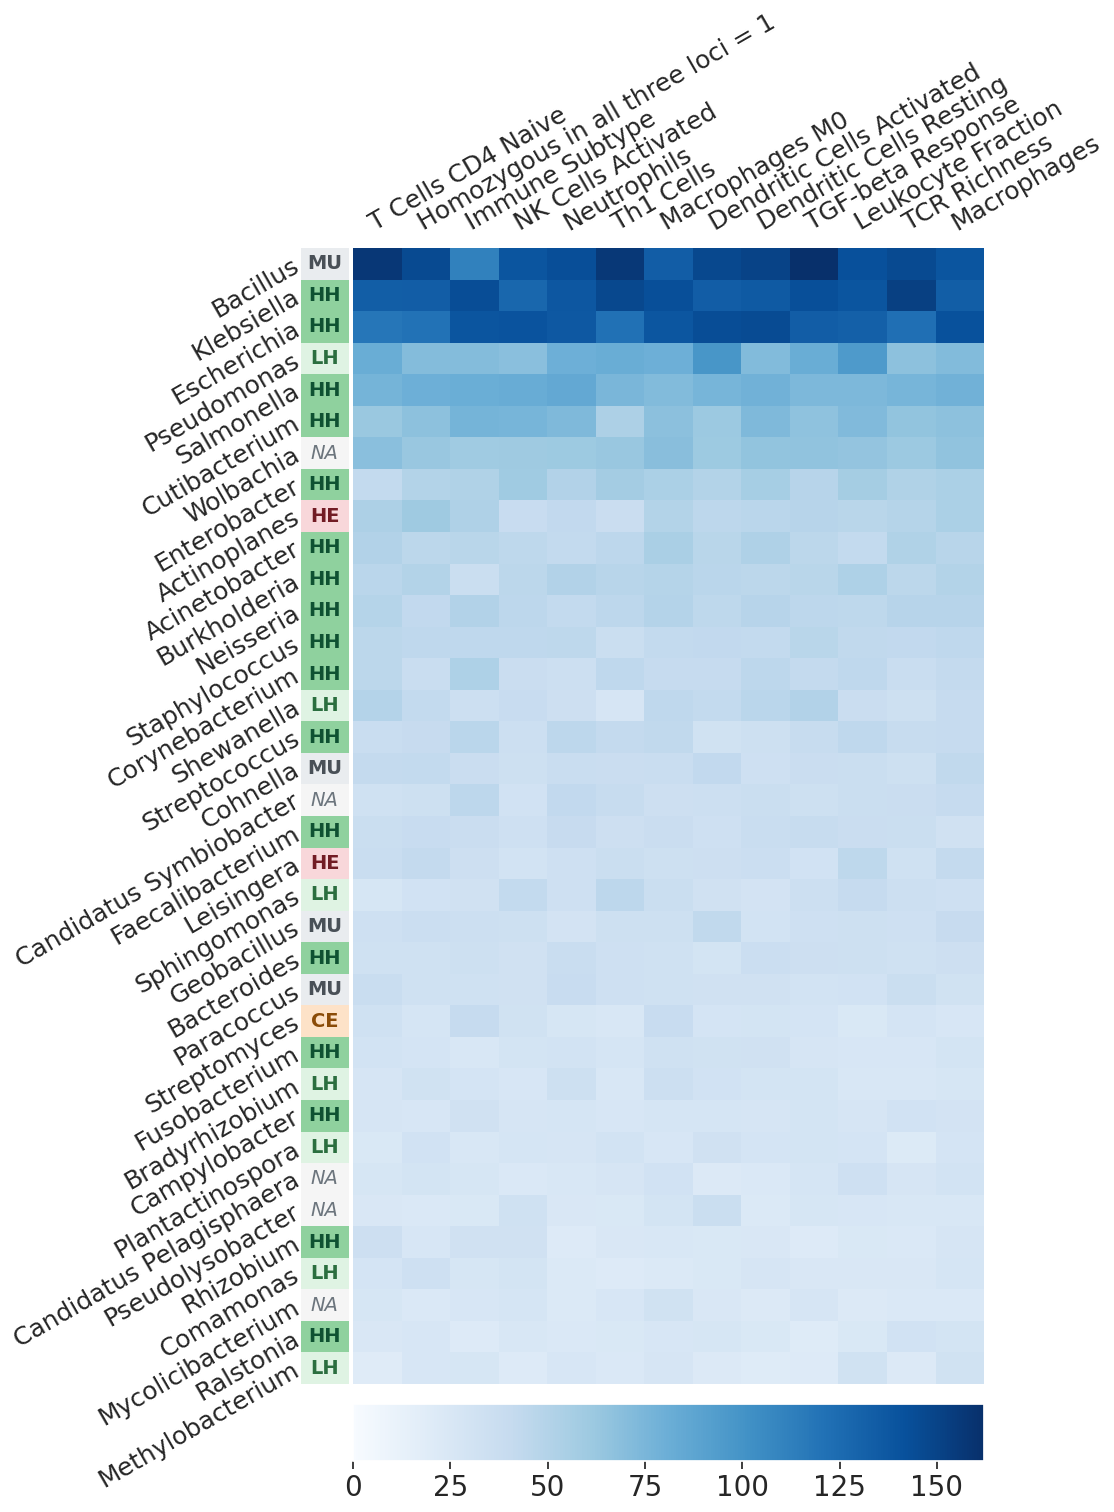

In [113]:
COAD_sorted_influence_df_subset = heatmap_influence(
    'COAD',
    COAD_sorted_influence_df,
    cmap="Blues", #"Blues", "YlOrBr", "Reds"
    cbar=True,
    top_col_pct=0.02,
    save=True,
    taxa_names=True,
    horizontal=False,
    add_ecology_bar=True,
    row_label_fontsize=18,
    col_label_fontsize=18,
    anno_label_fontsize=14,
    colorbar_tick_fontsize=20
)

In [55]:
COAD_sorted_influence_df_subset

,Bacillus,Klebsiella,Escherichia,Pseudomonas,Salmonella,Cutibacterium,Wolbachia,Enterobacter,Actinoplanes,Acinetobacter,...,Parachlamydia,Salinibaculum,Actinotalea,Cycloclasticus,Rhodomicrobium,Defluviitoga,Desulfosudis,Candidatus Arcticimaribacter,Polaribacter,Kangiella
T Cells CD4 Naive,157.247116,133.262573,118.415436,81.751282,77.037521,62.656124,68.628273,42.351635,53.225468,51.091427,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Homozygous in all three loci = 1,145.740738,133.962204,120.939789,71.307236,80.177956,67.440720,63.331051,50.256195,60.557430,45.976707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Immune Subtype,111.928673,144.109055,139.230347,71.021538,81.434677,76.910805,60.040157,51.386330,52.301342,47.091702,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NK Cells Activated,139.179993,127.835136,140.279083,68.859756,82.820099,76.354424,60.357899,59.721565,39.053196,44.468243,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Neutrophils,143.285934,137.976105,137.398758,79.809776,85.481949,73.441269,61.069763,50.960400,42.619278,42.310528,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Th1 Cells,156.717651,147.364685,121.249321,81.749031,75.221237,53.438343,63.052799,57.651512,37.799866,45.006824,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophages M0,134.147369,142.810181,138.343048,80.433342,71.708641,68.056114,69.300522,54.016747,50.616413,54.606071,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dendritic Cells Activated,147.216446,134.260361,144.410995,98.605125,76.258759,61.461533,60.918217,50.136925,45.481655,47.071407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dendritic Cells Resting,150.701462,136.049454,145.259476,71.951675,78.703979,73.005463,65.357468,56.454899,46.260700,52.073277,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TGF-beta Response,162.146072,142.972107,133.864487,82.213577,73.940331,66.840965,66.464874,48.295490,48.497738,45.943203,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [151]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
import math

def draw_ecology_annotation_legend_2x3(
    save_path,
    fontsize=12,
    text_fontsize=20
):
    items = [
        ("HH", "Highly likely host-associated", "#8fd19e", "#0f5132", "bold", "normal"),
        ("LH", "Likely host-associated", "#dff3e3", "#2b6e3f", "bold", "normal"),
        ("MU", "Mixed or uncertain", "#e9ecef", "#495057", "bold", "normal"),
        ("CE", "Could be environmental", "#fde2c8", "#8a4b08", "bold", "normal"),
        ("HE", "Highly likely environmental", "#f8d7da", "#721c24", "bold", "normal"),
        ("NA", "No BacDive data", "#f5f5f5", "#6c757d", "normal", "italic"),
    ]

    n_cols = 3
    n_rows = 2

    fig, ax = plt.subplots(figsize=(18, 2.2))  # wider figure
    ax.axis("off")

    col_x = [0.5, 5.5, 10.5]

    # y positions for 2 rows (top → bottom)
    row_y = [1.1, 0.5]

    box_w = 0.6
    box_h = 0.45

    for idx, (abbr, label, bg, fg, weight, style) in enumerate(items):
        # row-wise filling: left → right, then next row
        row = idx // n_cols
        col = idx % n_cols

        x = col_x[col]
        y = row_y[row]

        rect = Rectangle(
            (x, y),
            box_w,
            box_h,
            facecolor=bg,
            edgecolor="#cccccc",
            linewidth=0.6
        )
        ax.add_patch(rect)

        ax.text(
            x + box_w / 2,
            y + box_h / 2,
            abbr,
            ha="center",
            va="center",
            fontsize=fontsize,
            color=fg,
            fontweight=weight,
            fontstyle=style
        )

        ax.text(
            x + box_w + 0.25,
            y + box_h / 2,
            label,
            ha="left",
            va="center",
            fontsize=text_fontsize
        )

    ax.set_xlim(0, max(col_x) + 3)
    ax.set_ylim(0, 2.2)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

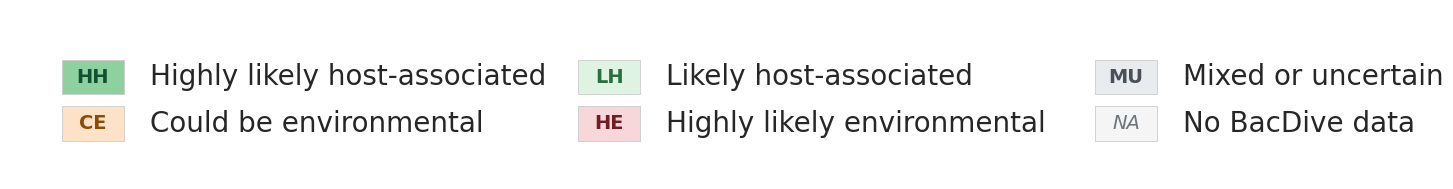

In [152]:
draw_ecology_annotation_legend_2x3(
    save_path="./figures/ecology_annotation_legend.pdf",
    fontsize=14
)

---

In [95]:
STAD_sorted_influence_df = sort_influence('STAD')

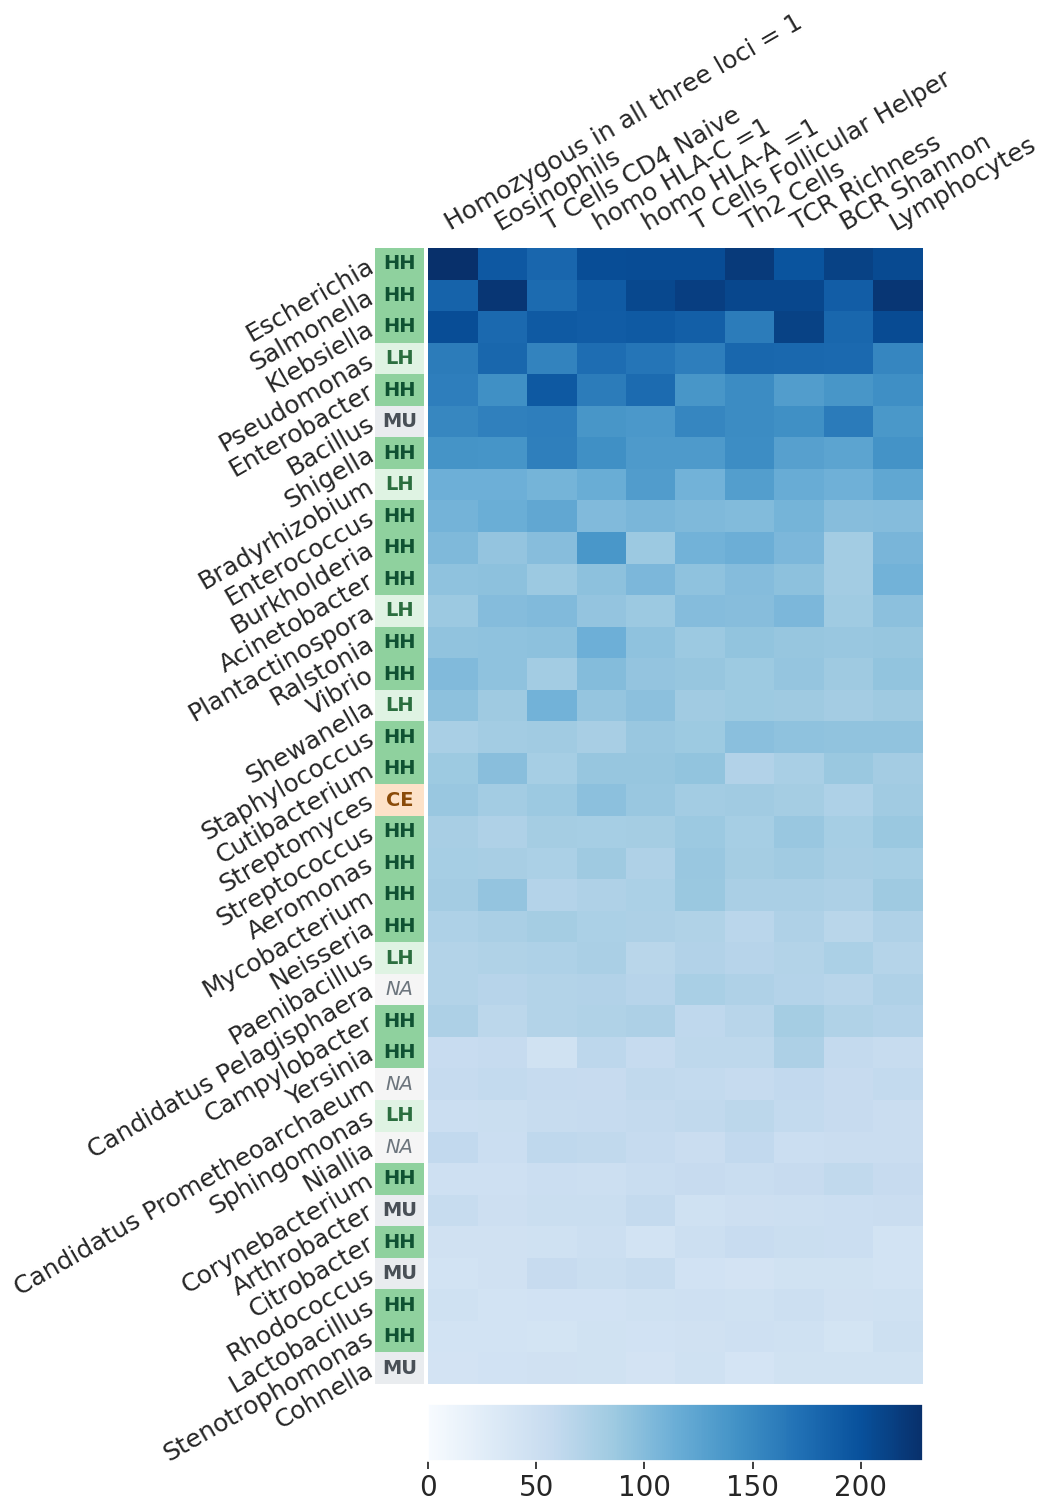

In [114]:
STAD_sorted_influence_df_subset = heatmap_influence(
    'STAD',
    STAD_sorted_influence_df,
    cmap="Blues", #"Blues", "YlOrBr", "Reds"
    cbar=True,
    top_col_pct=0.02,
    save=True,
    taxa_names=True,
    horizontal=False,
    add_ecology_bar=True,
    row_label_fontsize=18,
    col_label_fontsize=18,
    anno_label_fontsize=14,
    colorbar_tick_fontsize=20
)

In [63]:
STAD_sorted_influence_df_subset

,Escherichia,Salmonella,Klebsiella,Pseudomonas,Enterobacter,Bacillus,Shigella,Bradyrhizobium,Enterococcus,Burkholderia,...,Candidatus Hepatoplasma,Rasiella,Zunongwangia,Carboxydocella,Marivivens,Octadecabacter,Longicatena,Faecalibacillus,Profundibacter,Floricoccus
Homozygous in all three loci = 1,228.678925,183.807541,203.035339,161.922104,160.624466,152.297867,140.527130,113.037682,109.559860,102.886757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Eosinophils,193.788025,222.953964,178.034760,180.010910,144.557327,158.434036,139.759155,112.633774,115.099434,91.170128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
T Cells CD4 Naive,180.697357,176.577423,191.979172,156.004761,192.506226,160.229980,159.611969,108.545044,121.232750,98.408478,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
homo HLA-C =1,203.037674,190.270233,189.821945,174.387527,162.283264,138.610031,144.343109,116.090569,102.299301,137.996201,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
homo HLA-A =1,204.248199,207.331482,191.588089,167.148148,176.328491,136.504669,134.210709,133.075928,105.826851,87.006172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
T Cells Follicular Helper,204.121384,215.492310,187.104813,160.233658,138.615311,153.095856,134.663956,110.646423,103.064034,110.571922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Th2 Cells,219.307510,208.830811,162.122223,180.244629,147.758667,147.652679,147.267731,130.957779,101.444458,113.825241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCR Richness,196.813416,208.335556,213.132950,178.964523,131.810471,144.432327,128.036087,116.945869,108.521843,104.879868,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BCR Shannon,212.880905,188.522659,179.982666,178.630920,138.642578,162.654465,125.033188,112.315430,98.369087,83.004395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Lymphocytes,206.133896,222.530655,205.126221,152.892792,145.376099,137.381409,141.466797,121.558670,99.948898,107.046371,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
## Save LRP results seperately

In [64]:
def save_data_n_lrp(disease, save_folder='./', data_save_folder='../data/saved_data'):
    immune_variables_disease_microbiome_clean = \
        pd.read_pickle('./data/processed data/{}_immune_variables_disease_microbiome_clean.pkl'.format(disease))
    X_microbiome = pd.read_pickle('./data/processed data/{}_microbiome_clean.pkl'.format(disease))
    col_idx = immune_variables_disease_microbiome_clean.shape[1] - X_microbiome.shape[1] - 4
    y_immune_all = immune_variables_disease_microbiome_clean.iloc[:, 2:col_idx]
    data_save_folder1 = os.path.join(data_save_folder, f'{disease}')
    os.makedirs(data_save_folder1, exist_ok=True)
    X_microbiome.to_csv(os.path.join(data_save_folder1, 'X_microbiome.csv'))
    y_immune_all.to_csv(os.path.join(data_save_folder1, 'y_immune_all_cols.csv'))
    
    import pickle
    result_save_folder = os.path.join(save_folder, 'results/LRP/{}'.format(disease))
    os.makedirs(result_save_folder, exist_ok=True)
    with open(os.path.join(result_save_folder, 'lrp_result_dict.pkl'.format(disease)), "rb") as f:
        lrp_result_dict = pickle.load(f)
    
    R_0_immune_all = lrp_result_dict['R_0_immune_all']
    y_col_names = lrp_result_dict['y_col_names']
    
    for i, col in enumerate(y_col_names):
        classifier, optimizer, hist, X_test, y_test_le, classes, X_nonan, y_nonan_disc = \
            load_model(X=X_microbiome, y=y_immune_all[col],
                       disease=disease, dropout_rate=0.4, weight_decay=0.1)
        R_0_df = pd.DataFrame(R_0_immune_all[i], index=X_nonan.index, columns=X_nonan.columns)
        data_save_folder2 = os.path.join(data_save_folder, f'{disease}/{col}')
        os.makedirs(data_save_folder2, exist_ok=True)
        R_0_df.to_csv(os.path.join(data_save_folder2, 'R_0.csv'))
        X_nonan.to_csv(os.path.join(data_save_folder2, 'X_microbiome_nonan.csv'))
        

In [65]:
save_data_n_lrp('COAD')
save_data_n_lrp('STAD')

In [66]:
save_data_n_lrp('LUAD')
save_data_n_lrp('LUSC')